# California Real Estate — Exploratory Data Analysis

**Data Source:** CRMLS (California Regional Multiple Listing Service) via CoreLogic Trestle API  
**Coverage:** January 2024 — March 2026 (27 months)  
**Datasets:**
- `priceratio.csv` — Closed residential transactions with derived market metrics
- `newlistings.csv` — New residential listings

**Objective:** Identify meaningful patterns and relationships in the California housing market to inform the construction of market analysis and competitive analysis Tableau dashboards.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Add project root to path so we can import our modules
sys.path.insert(0, os.path.abspath('..'))

from data_cleaning.helpers.duplicates import drop_duplicate_columns
from data_cleaning.helpers.dates import parse_sold_dates, parse_listing_dates
from data_cleaning.helpers.missing import missing_value_report
from data_cleaning.helpers.outliers import flag_outliers, filter_outliers
from data_cleaning.helpers.mortgage_rates import load_mortgage_rates, merge_mortgage_rates
from data_cleaning.helpers.dates import parse_all_date_fields, add_date_consistency_flags
from data_cleaning.helpers.validation import flag_invalid_numerics
from data_cleaning.helpers.geographic import flag_invalid_coordinates

from feature_engineering.helpers.engineer_features import (
    add_market_condition, add_price_reduction_flags,
    add_dom_buckets, add_price_tiers
)
from feature_engineering.add_new_features import engineer_sold_features, engineer_listing_features

from exploratory_analysis.helpers.visualize import (
    plot_missing_values, plot_boxplots, plot_sold_distributions,
    plot_listing_distributions, plot_monthly_kpi_trends, plot_yoy_comparison,
    plot_supply_vs_demand, plot_top_counties, plot_top_cities,
    plot_subtype_comparison, plot_price_vs_size, plot_dom_bucket_analysis,
    plot_price_reductions, plot_top_offices, plot_top_agents,
    plot_correlation_heatmap, plot_close_vs_list, plot_price_tiers,
    plot_new_construction
)
from exploratory_analysis.helpers.stats import (
    monthly_sold_summary, monthly_listing_summary, geographic_summary,
    dom_bucket_summary, competitive_summary, price_tier_summary,
    percentile_summary, segment_summary, market_summary
)

---
## 1. Load Data


In [4]:
sold = pd.read_csv('../data/priceratio.csv', encoding='ISO-8859-1')
listings = pd.read_csv('../data/newlistings.csv', encoding='ISO-8859-1')

print(f"Sold transactions: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"New listings:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold transactions: 397,887 rows x 49 columns
New listings:      514,182 rows x 84 columns


### Property Type Breakdown

Document the unique property types in each dataset before filtering.


In [5]:
# Unique property types in sold data
if 'PropertyType' in sold.columns:
    print('=== Sold — Property Types ===')
    print(sold['PropertyType'].value_counts())
    print(f'\nTotal unique: {sold["PropertyType"].nunique()}')
else:
    print('PropertyType column not found — dataset is pre-filtered to Residential')

if 'PropertyType' in listings.columns:
    print('\n=== Listings — Property Types ===')
    print(listings['PropertyType'].value_counts())
    print(f'\nTotal unique: {listings["PropertyType"].nunique()}')
else:
    print('PropertyType column not found — dataset is pre-filtered to Residential')


=== Sold — Property Types ===
PropertyType
Residential    397887
Name: count, dtype: int64

Total unique: 1

=== Listings — Property Types ===
PropertyType
Residential    514182
Name: count, dtype: int64

Total unique: 1


---
## 2. Data Overview

Inspect schema, data types, and summary statistics for both datasets.


In [6]:
print("=== Sold Transactions (priceratio.csv) ===")
print(f"Columns: {sold.columns.tolist()}")
sold.info()

=== Sold Transactions (priceratio.csv) ===
Columns: ['OriginalListPrice', 'ListingKey', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'CountyOrParish', 'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate', 'StateOrProvince', 'CoveredSpaces', 'Stories', 'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'PostalCode', 'LotSizeSquareFeet', 'OriginatingSystemName', 'OriginatingSystemSubName', 'priceratio', 'pricesqft']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397887 entries, 0 to 3978

In [7]:
sold.describe()


,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,BuildingAreaTotal,BedroomsTotal,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,LotSizeSquareFeet,priceratio,pricesqft
count,397163.00,397887.00,397885.00,393841.00,393841.00,397658.00,397887.00,369077.00,0.00,397457.00,366499.00,397529.00,397818.00,27810.00,397876.00,0.00,336350.00,367000.00,230902.00,380826.00,366876.00,359948.00,397656.00
mean,1224529.64,1095940684.89,1184508.20,34.70,-118.63,1904.26,1138489.57,27.31,NaN,9.32,68.51,1978.57,2.53,2118.74,3.20,NaN,1.36,38397.95,2.06,1.86,334524.63,0.99,inf
std,6777444.34,29947657.83,5903733.69,1.74,2.96,27008.17,1353408.39,27.88,NaN,4114.21,16321.44,26.27,1.14,1704.75,1.07,NaN,0.48,2138976.84,7.24,3.71,16300940.43,0.05,NaN
min,0.00,421678487.00,0.00,-117.47,-177.65,0.00,525.00,-65.00,NaN,-143.00,0.00,1776.00,0.00,0.00,0.00,NaN,1.00,0.00,0.00,0.00,0.00,0.83,0.00
25%,585000.00,1075078771.50,575000.00,33.74,-119.15,1247.00,575000.00,7.00,NaN,2.00,0.12,1960.00,2.00,1270.00,3.00,NaN,1.00,5000.00,1.00,2.00,5227.00,0.96,368.42
50%,825000.00,1094688745.00,820000.00,34.05,-118.03,1641.00,815000.00,16.00,NaN,2.00,0.17,1979.00,2.00,1714.00,3.00,NaN,1.00,7015.00,2.00,2.00,7242.00,1.00,537.38
75%,1299000.00,1115111064.50,1300000.00,34.71,-117.27,2217.00,1295000.00,39.00,NaN,3.00,0.27,1999.00,3.00,2458.00,4.00,NaN,2.00,10890.00,3.00,2.00,11836.00,1.02,732.44
max,1390000000.00,1156789232.00,989500000.00,56.13,329.00,17021321.00,137500000.00,168.00,NaN,2593669.00,7810698.36,2026.00,175.00,123764.00,45.00,NaN,2.00,918742280.00,3333.00,600.00,2208317760.00,1.15,inf


In [8]:
print("=== New Listings (newlistings.csv) ===")
print(f"Columns: {listings.columns.tolist()}")
listings.info()

=== New Listings (newlistings.csv) ===
Columns: ['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation', 'TaxYear', 'Buildi

In [9]:
listings.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,ListingKeyNumeric,TaxAnnualAmount,ParkingTotal,LotSizeAcres,YearBuilt,DaysOnMarket.1,StreetNumberNumeric,LivingArea.1,BathroomsTotalInteger,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,Longitude.1,ElementarySchoolDistrict,BelowGradeFinishedArea,BusinessType,Latitude.1,ListPrice.1,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,513447.00,514182.00,145855.00,434335.00,434335.00,513656.00,514182.00,514182.00,0.00,0.00,514182.00,0.00,514162.00,471786.00,513309.00,514182.00,513390.00,513656.00,514127.00,78993.00,0.00,45572.00,514049.00,434335.00,0.00,2856.00,0.00,434335.00,514182.00,0.00,424901.00,472585.00,280211.00,485699.00,390710.00,472416.00,0.00
mean,1396197.53,1102248796.84,1196611.44,34.59,-118.45,1980.11,1310238.66,20.05,NaN,NaN,1102248796.84,NaN,7.86,65.98,1979.53,20.05,11573.71,1980.11,2.62,189.11,NaN,2439.41,3.22,-118.45,NaN,86.79,NaN,34.59,1310238.66,NaN,1.37,47179.74,2.05,1.85,269.43,410696.60,NaN
std,7441658.40,28338091.66,4285442.05,2.01,3.47,23964.85,2349986.14,27.34,NaN,NaN,28338091.66,NaN,3617.29,12409.20,26.98,27.34,285923.58,23964.85,3.33,2340.72,NaN,2251.44,1.18,3.47,NaN,361.49,NaN,2.01,2349986.14,NaN,0.48,2225516.97,6.59,3.88,2423.71,20878085.59,NaN
min,0.00,1018357250.00,525.00,-117.47,-159.48,0.00,100.00,-58.00,NaN,NaN,1018357250.00,NaN,-143.00,0.00,1776.00,-58.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,-159.48,NaN,0.00,NaN,-117.47,100.00,NaN,1.00,0.00,0.00,0.00,0.00,0.00,NaN
25%,585000.00,1077035641.00,600000.00,33.74,-118.65,1246.00,580000.00,5.00,NaN,NaN,1077035641.00,NaN,2.00,0.12,1961.00,5.00,977.00,1246.00,2.00,2.00,NaN,1305.00,2.00,-118.65,NaN,0.00,NaN,33.74,580000.00,NaN,1.00,5000.00,1.00,1.00,0.00,5227.00,NaN
50%,849000.00,1103158605.50,850000.00,34.05,-118.02,1668.00,839950.00,11.00,NaN,NaN,1103158605.50,NaN,2.00,0.17,1980.00,11.00,3269.00,1668.00,2.00,2.50,NaN,1822.00,3.00,-118.02,NaN,0.00,NaN,34.05,839950.00,NaN,1.00,7193.00,2.00,2.00,125.00,7405.00,NaN
75%,1387500.00,1118957054.50,1350000.00,34.46,-117.24,2297.00,1375000.00,23.00,NaN,NaN,1118957054.50,NaN,3.00,0.31,2001.00,23.00,12059.00,2297.00,3.00,2.50,NaN,2789.00,4.00,-117.24,NaN,0.00,NaN,34.46,1375000.00,NaN,2.00,12000.00,3.00,2.00,400.00,13520.00,NaN
max,1390000000.00,1156084894.00,820000000.00,737.00,329.00,17021321.00,195000000.00,731.00,NaN,NaN,1156084894.00,NaN,2593669.00,4187292.00,2028.00,731.00,79547958.00,17021321.00,2208.00,200000.00,NaN,123764.00,94.00,329.00,NaN,5000.00,NaN,737.00,195000000.00,NaN,2.00,918742280.00,3333.00,600.00,968348.00,7638115320.00,NaN


---
## 3. Data Cleaning

### 3a. Handle Duplicate Columns in Listings

The  file contains duplicate column names from the API extraction. These are redundant and should be dropped before analysis.


In [10]:
listings = drop_duplicate_columns(listings)

Duplicate columns to drop (11):
['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'CloseDate.1', 'BuyerOfficeName.1', 'UnparsedAddress.1']

Shape after dropping duplicates: (514182, 73)


### 3b. Parse Date Columns and Create Time Features

In [11]:
sold = parse_sold_dates(sold)
listings = parse_listing_dates(listings)

Sold date range: 2024-01-01 to 2026-03-31
Listings date range: 2024-01-01 to 2026-02-28


### 3c. Mortgage Rate Enrichment

Merge the 30-year fixed mortgage rate (FRED MORTGAGE30US) onto both datasets.
Weekly rates are resampled to monthly averages and joined on a year-month key.


In [12]:
mortgage_monthly = load_mortgage_rates('../data/MORTGAGE30US.csv')

sold = merge_mortgage_rates(sold, mortgage_monthly, date_col='CloseDate')
listings = merge_mortgage_rates(listings, mortgage_monthly, date_col='ListingContractDate')

# Preview the merge
print(sold[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())


Mortgage rates loaded: 661 months (1971-04 to 2026-04)
Merged on CloseDate: 0 rows with null rate (0.00%)
Merged on ListingContractDate: 0 rows with null rate (0.00%)
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01   240000.00             6.64
1 2024-01-05    2024-01   815000.00             6.64
2 2024-01-05    2024-01   810000.00             6.64
3 2024-01-02    2024-01  2100000.00             6.64
4 2024-01-22    2024-01  1950000.00             6.64


In [13]:
# Save enriched datasets with mortgage rates
sold.to_csv('../data/mortgage_enriched/sold_with_rates.csv', index=False)
listings.to_csv('../data/mortgage_enriched/listings_with_rates.csv', index=False)

print(f'Saved sold_with_rates.csv: {sold.shape[0]:,} rows')
print(f'Saved listings_with_rates.csv: {listings.shape[0]:,} rows')


Saved sold_with_rates.csv: 397,887 rows
Saved listings_with_rates.csv: 514,182 rows


### 3d. Data Validation — Weeks 4-5

Apply validation checks, date consistency flags, and geographic quality flags.
These steps prepare the dataset for reliable analytics.


### Parse All Date Fields

Convert CloseDate, PurchaseContractDate, ListingContractDate, and ContractStatusChangeDate to datetime.


In [14]:
sold = parse_all_date_fields(sold)
listings = parse_all_date_fields(listings)


Parsed 4 date columns: ['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']
Parsed 4 date columns: ['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']


### Date Consistency Checks

Flag records where dates violate logical ordering: ListingContractDate should precede PurchaseContractDate, which should precede CloseDate.


In [15]:
sold = add_date_consistency_flags(sold)


=== Date Consistency Flags ===
  listing_after_close_flag: 58 records (0.01%)
  purchase_after_close_flag: 239 records (0.06%)
  negative_timeline_flag: 295 records (0.07%)


### Invalid Numeric Value Flags

Flag records with ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0, or negative bedrooms/bathrooms.


In [16]:
sold = flag_invalid_numerics(sold)
listings = flag_invalid_numerics(listings)


=== Invalid Numeric Value Flags ===
  invalid_close_price: 1 records (0.00%)
  invalid_living_area: 144 records (0.04%)
  invalid_dom: 38 records (0.01%)
  invalid_bedrooms: 0 records (0.00%)
  invalid_bathrooms: 0 records (0.00%)
  any_invalid_flag: 183 records (0.05%)
=== Invalid Numeric Value Flags ===
  invalid_close_price: 0 records (0.00%)
  invalid_living_area: 339 records (0.07%)
  invalid_dom: 29 records (0.01%)
  invalid_bedrooms: 0 records (0.00%)
  invalid_bathrooms: 0 records (0.00%)
  any_invalid_flag: 368 records (0.07%)


### Geographic Data Quality

Flag records with missing/zero coordinates, positive longitude (should be negative in CA), and out-of-state coordinates.


In [17]:
sold = flag_invalid_coordinates(sold)
listings = flag_invalid_coordinates(listings)


=== Geographic Data Quality Flags ===
  missing_coords_flag: 4,046 records (1.02%)
  zero_coords_flag: 25 records (0.01%)
  positive_lon_flag: 29 records (0.01%)
  out_of_state_flag: 62 records (0.02%)
  any_geo_flag: 4,133 records (1.04%)
=== Geographic Data Quality Flags ===
  missing_coords_flag: 79,847 records (15.53%)
  zero_coords_flag: 56 records (0.01%)
  positive_lon_flag: 65 records (0.01%)
  out_of_state_flag: 230 records (0.04%)
  any_geo_flag: 80,133 records (15.58%)


### Cleaning Summary & Save

Report before/after row counts and save the cleaned dataset.


In [18]:
# Before/after summary
print('=== Cleaning Summary — Sold ===')
print(f'Total rows: {len(sold):,}')
if 'negative_timeline_flag' in sold.columns:
    print(f'Date inconsistencies: {sold["negative_timeline_flag"].sum():,}')
if 'any_invalid_flag' in sold.columns:
    print(f'Invalid numeric values: {sold["any_invalid_flag"].sum():,}')
if 'any_geo_flag' in sold.columns:
    print(f'Geographic issues: {sold["any_geo_flag"].sum():,}')

print('\n=== Cleaning Summary — Listings ===')
print(f'Total rows: {len(listings):,}')
if 'any_invalid_flag' in listings.columns:
    print(f'Invalid numeric values: {listings["any_invalid_flag"].sum():,}')
if 'any_geo_flag' in listings.columns:
    print(f'Geographic issues: {listings["any_geo_flag"].sum():,}')

# Save cleaned datasets
sold.to_csv('../data/cleaned_sold.csv', index=False)
listings.to_csv('../data/cleaned_lis' \
'tings.csv', index=False)
print(f'\nSaved cleaned_sold.csv: {len(sold):,} rows')
print(f'Saved cleaned_listings.csv: {len(listings):,} rows')


=== Cleaning Summary — Sold ===
Total rows: 397,887
Date inconsistencies: 295
Invalid numeric values: 183
Geographic issues: 4,133

=== Cleaning Summary — Listings ===
Total rows: 514,182
Invalid numeric values: 368
Geographic issues: 80,133

Saved cleaned_sold.csv: 397,887 rows
Saved cleaned_listings.csv: 514,182 rows


### 3e. Missing Data Analysis

In [19]:
sold_missing = missing_value_report(sold, "Sold Transactions")

=== Sold Transactions: 41 columns with missing values ===
                          Missing Count  Missing %
CoveredSpaces                    397887     100.00
FireplacesTotal                  397887     100.00
LotSizeDimensions                378558      95.14
BuildingAreaTotal                370077      93.01
OriginatingSystemSubName         359462      90.34
OriginatingSystemName            359462      90.34
CoListOfficeName                 303743      76.34
SubdivisionName                  250064      62.85
MainLevelBedrooms                166985      41.97
Stories                           61537      15.47
AttachedGarageYN                  60726      15.26
Levels                            38574       9.69
priceratio                        37939       9.54
LotSizeAcres                      31388       7.89
LotSizeSquareFeet                 31011       7.79
LotSizeArea                       30887       7.76
NewConstructionYN                 29493       7.41
DaysOnMarket            

In [20]:
list_missing = missing_value_report(listings, "New Listings")

=== New Listings: 63 columns with missing values ===
                              Missing Count  Missing %
MiddleOrJuniorSchoolDistrict         514182     100.00
FireplacesTotal                      514182     100.00
CoveredSpaces                        514182     100.00
BusinessType                         514182     100.00
ElementarySchoolDistrict             514182     100.00
...                                     ...        ...
StateOrProvince                          46       0.01
BathroomsTotalInteger                    55       0.01
ListAgentLastName                        42       0.01
ParkingTotal                             20       0.00
PostalCode                               13       0.00

[63 rows x 2 columns]


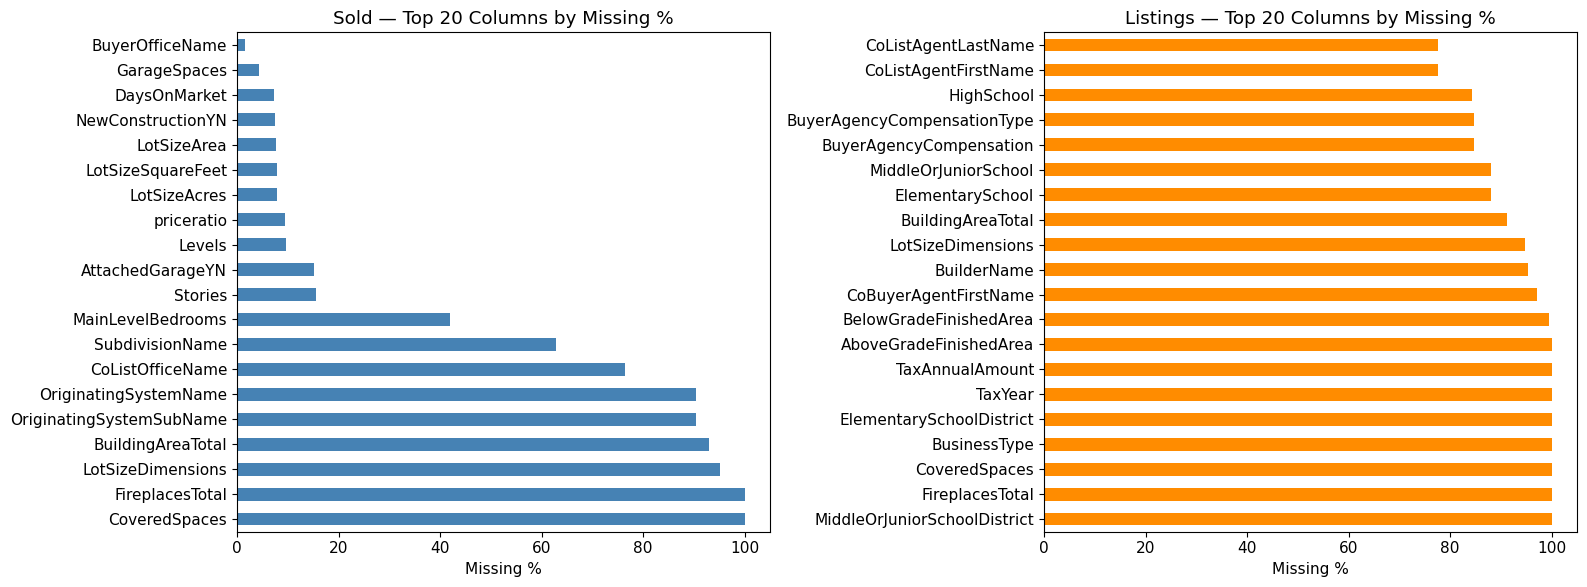

In [21]:
plot_missing_values(sold_missing, list_missing)

### 3f. Outlier Assessment

The  and  fields in the sold dataset already have IQR-based outlier handling applied (outliers replaced with NaN in ). Here we examine the remaining distributions for any additional anomalies in key numeric fields.


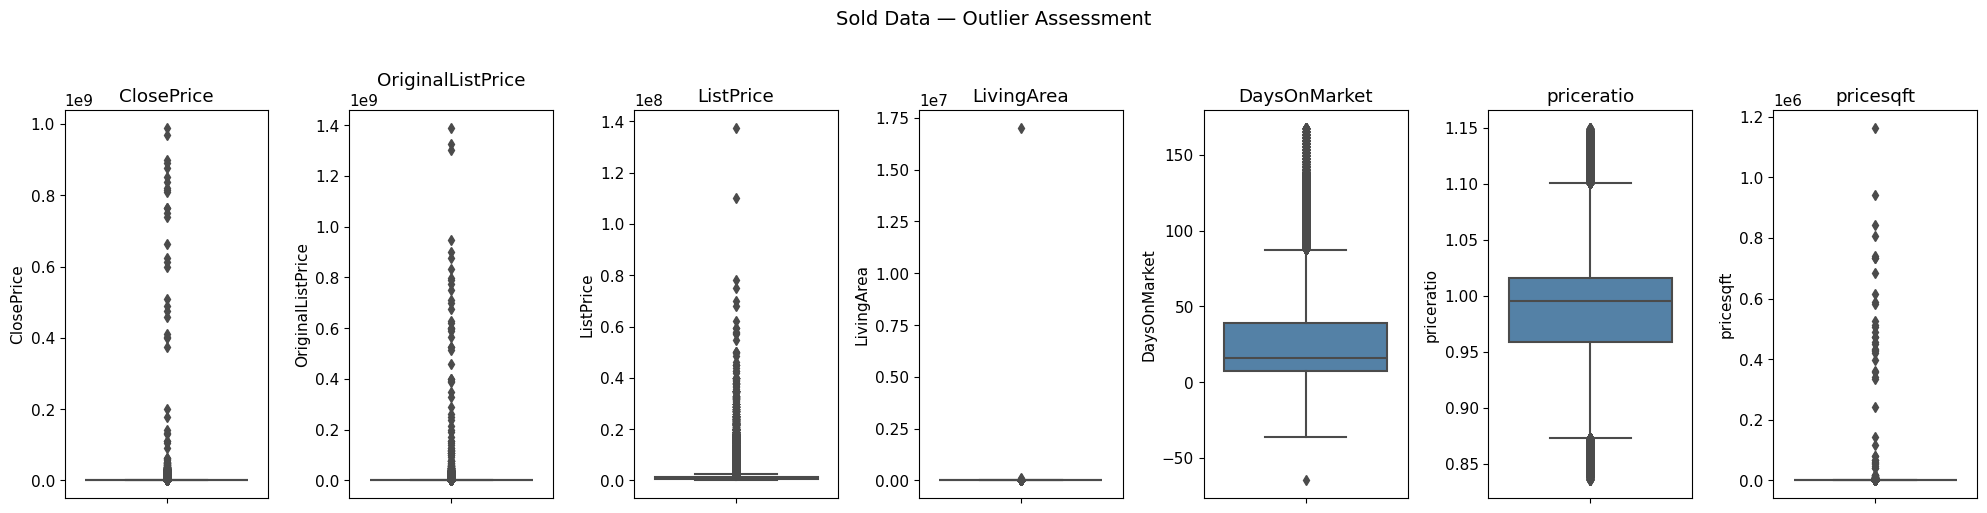

In [22]:
sold_numeric_cols = ['ClosePrice', 'OriginalListPrice', 'ListPrice', 'LivingArea',
                     'DaysOnMarket', 'priceratio', 'pricesqft']
plot_boxplots(sold, sold_numeric_cols, 'Sold Data — Outlier Assessment', color='steelblue')

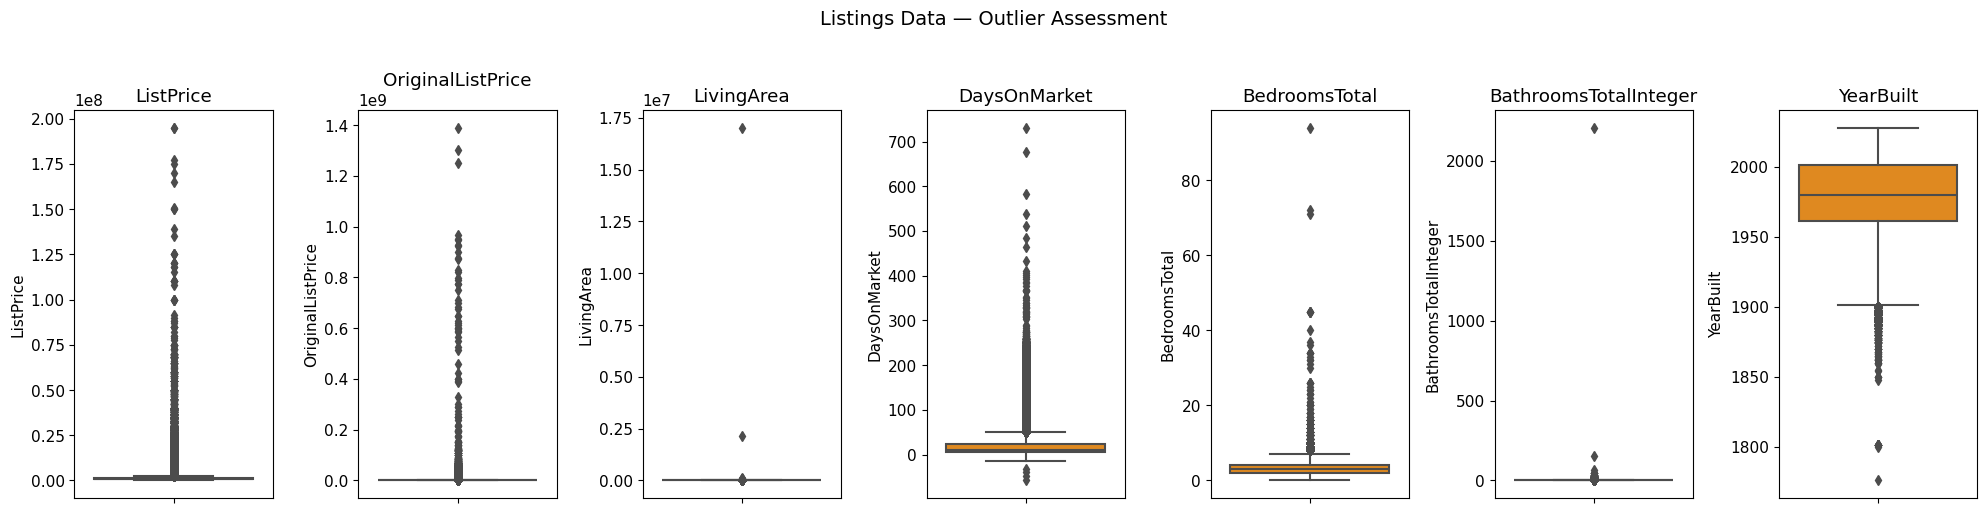

In [23]:
list_numeric_cols = ['ListPrice', 'OriginalListPrice', 'LivingArea', 'DaysOnMarket',
                     'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt']
plot_boxplots(listings, list_numeric_cols, 'Listings Data — Outlier Assessment', color='darkorange')

---
## 4. Distributions

Examine the shape of key numeric variables to understand skewness, central tendency, and spread. This informs whether we should use median vs. mean for aggregations and whether transformations are needed.


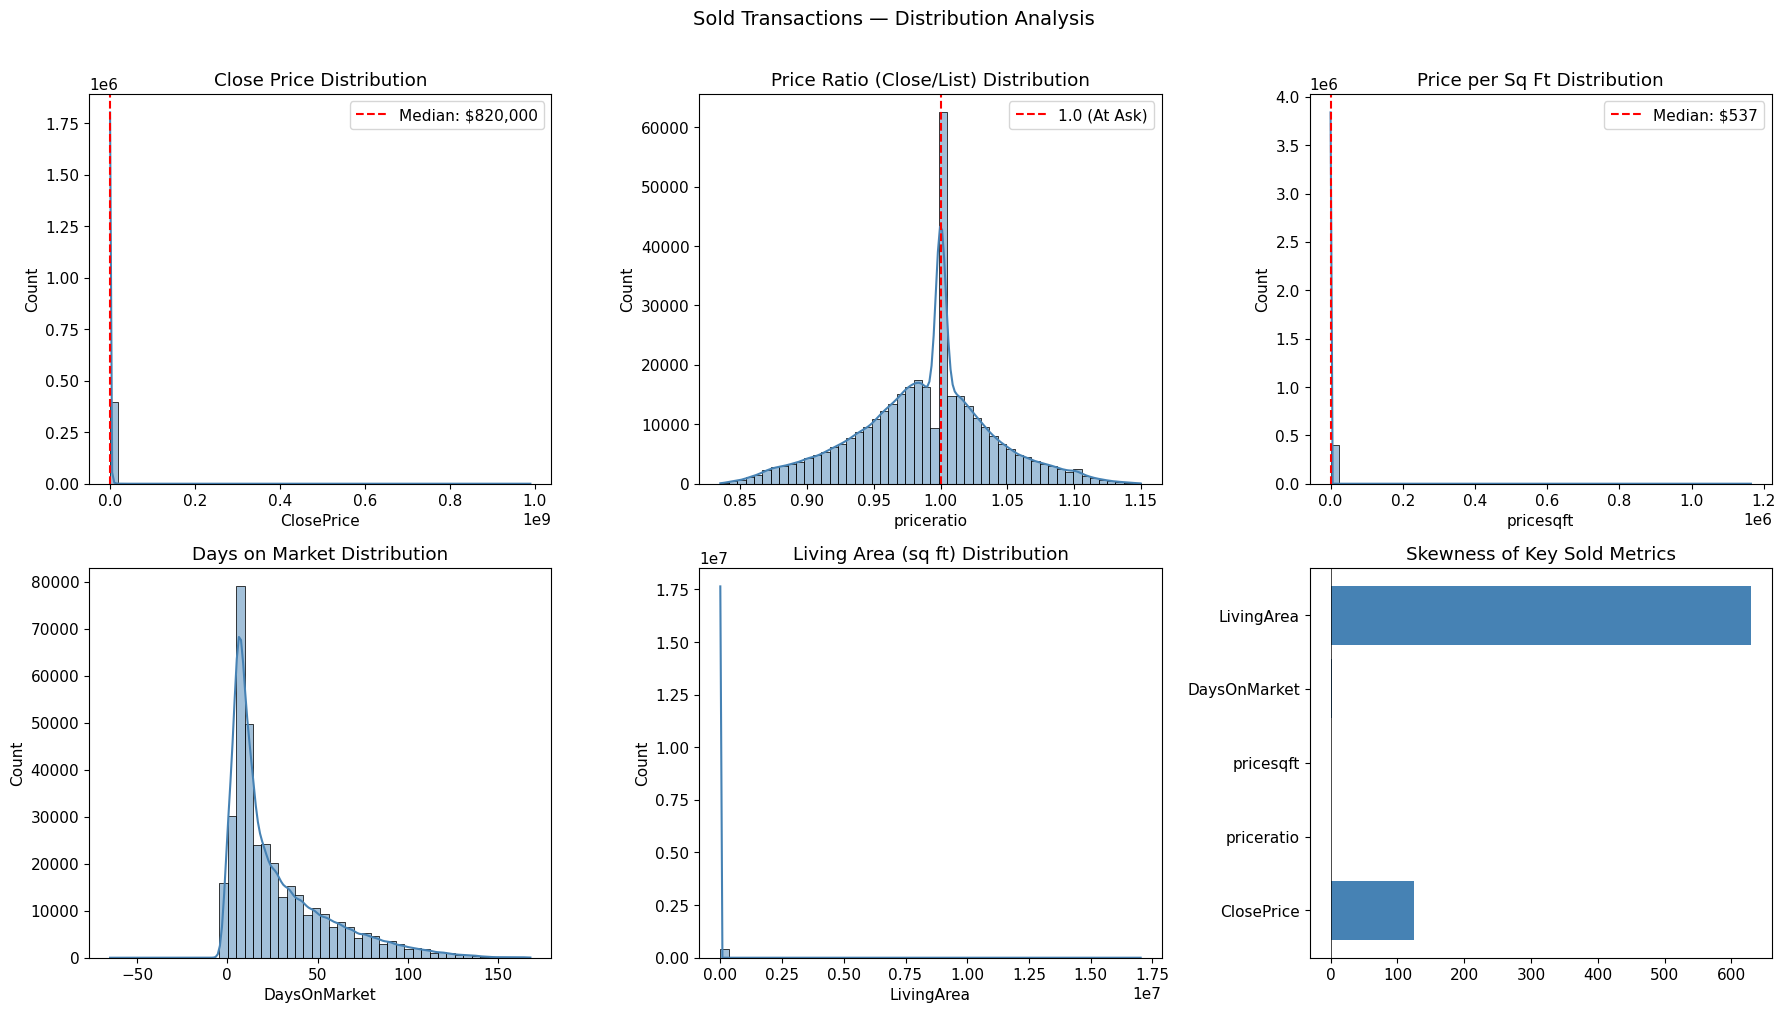

In [24]:
plot_sold_distributions(sold)

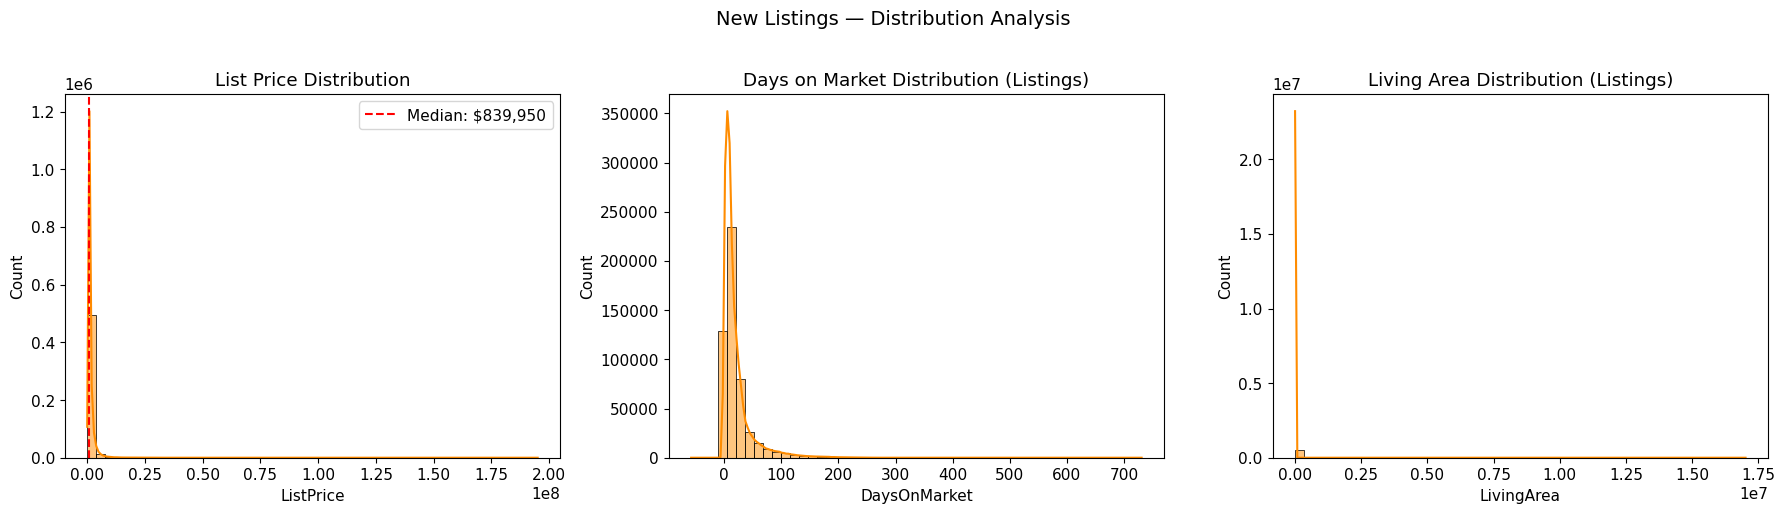

In [25]:
plot_listing_distributions(listings)

### Numeric Distribution Summary

Percentile table for key numeric fields


In [26]:
sold_percentiles = percentile_summary(sold, ['ClosePrice', 'LivingArea', 'DaysOnMarket'])
print('=== Sold Transactions — Numeric Distribution Summary ===')
print(sold_percentiles)
print()

list_percentiles = percentile_summary(listings, ['ListPrice', 'LivingArea', 'DaysOnMarket'])
print('=== New Listings — Numeric Distribution Summary ===')
print(list_percentiles)


=== Sold Transactions — Numeric Distribution Summary ===
                 Count    Min      25th    Median       Mean       75th  \
ClosePrice   397885.00   0.00 575000.00 820000.00 1184508.20 1300000.00   
LivingArea   397658.00   0.00   1247.00   1641.00    1904.26    2217.00   
DaysOnMarket 369077.00 -65.00      7.00     16.00      27.31      39.00   

                      Max  
ClosePrice   989500000.00  
LivingArea    17021321.00  
DaysOnMarket       168.00  

=== New Listings — Numeric Distribution Summary ===
                 Count    Min      25th    Median       Mean       75th  \
ListPrice    514182.00 100.00 580000.00 839950.00 1310238.66 1375000.00   
LivingArea   513656.00   0.00   1246.00   1668.00    1980.11    2297.00   
DaysOnMarket 514182.00 -58.00      5.00     11.00      20.05      23.00   

                      Max  
ListPrice    195000000.00  
LivingArea    17021321.00  
DaysOnMarket       731.00  


---
## 5. Feature Engineering

Create additional features that will be useful for both the EDA and the downstream Tableau dashboards.


In [27]:
sold = engineer_sold_features(sold)

--- Sold Data Features ---
Market condition: {"Buyer's Market": 221950, "Seller's Market": 175937}
Was reduced: {0: 289660, 1: 108227}
DOM buckets: {'0-7': 81068, '8-14': 77726, '15-30': 75295, '31-60': 70415, '61-90': 32650, '90+': 16060}
Price tiers: {'Under 300K': 13670, '300K-500K': 56777, '500K-750K': 102692, '750K-1M': 79133, '1M-2M': 104197, '2M+': 41415}
listing_to_contract_days: median=25 days, mean=45.1 days
contract_to_close_days: median=29 days, mean=31.7 days


In [28]:
listings = engineer_listing_features(listings)

--- Listings Data Features ---
Was reduced: {0: 425421, 1: 88761}
Price tiers: {'Under 300K': 17517, '300K-500K': 75041, '500K-750K': 127845, '750K-1M': 100704, '1M-2M': 130310, '2M+': 62765}


### Segment Analysis

Group key metrics by market dimensions to uncover patterns across property types, geographies, and offices.


In [29]:
# Segment by PropertySubType
segment_summary(sold, 'PropertySubType')



=== Segment Summary by PropertySubType (top 20) ===
                       homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
PropertySubType                                                                                                                                 
SingleFamilyResidence      297540     890000.00    26.47            0.99            532.31                       24.00                     29.00
Condominium                 65888     627673.50    30.87            0.98            565.61                       29.00                     28.00
Townhouse                   23360     805000.00    26.24            0.99            562.61                       21.00                     28.00
ManufacturedOnLand           5133     324000.00    32.68            0.97            225.69                       38.00                     34.00
Duplex                       2165     912000.00    29.16            0.98     

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
PropertySubType,,,,,,,
SingleFamilyResidence,297540,890000.00,26.47,0.99,532.31,24.00,29.00
Condominium,65888,627673.50,30.87,0.98,565.61,29.00,28.00
Townhouse,23360,805000.00,26.24,0.99,562.61,21.00,28.00
ManufacturedOnLand,5133,324000.00,32.68,0.97,225.69,38.00,34.00
Duplex,2165,912000.00,29.16,0.98,543.75,31.00,31.00
StockCooperative,1601,360000.00,28.17,0.98,395.00,31.00,45.00
Cabin,452,241250.00,39.94,0.96,291.54,56.00,30.00
Triplex,325,1100000.00,35.31,0.97,463.38,45.00,35.00
MixedUse,194,700000.00,43.38,0.97,433.37,67.00,32.00


In [30]:
# Segment by CountyOrParish
segment_summary(sold, 'CountyOrParish')



=== Segment Summary by CountyOrParish (top 20) ===
                 homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
CountyOrParish                                                                                                                            
Los Angeles           98879     900000.00    27.59            0.99            608.41                       25.00                     30.00
Riverside             55066     600000.00    33.75            0.98            320.97                       38.00                     29.00
San Diego             49060     895000.00    24.37            0.99            591.04                       21.00                     26.00
Orange                44751    1175000.00    24.71            0.99            671.98                       25.00                     29.00
San Bernardino        37160     530000.00    30.87            0.99            332.27                       32.00  

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
CountyOrParish,,,,,,,
Los Angeles,98879,900000.00,27.59,0.99,608.41,25.00,30.00
Riverside,55066,600000.00,33.75,0.98,320.97,38.00,29.00
San Diego,49060,895000.00,24.37,0.99,591.04,21.00,26.00
Orange,44751,1175000.00,24.71,0.99,671.98,25.00,29.00
San Bernardino,37160,530000.00,30.87,0.99,332.27,32.00,32.00
Alameda,18769,1135000.00,21.97,1.00,701.07,14.00,23.00
Contra Costa,18101,820000.00,23.97,0.99,520.46,15.00,23.00
Santa Clara,17856,1600000.00,18.39,1.01,967.54,9.00,25.00
Ventura,12341,865000.00,32.85,0.98,515.87,35.00,24.00


In [31]:
# Segment by ListOfficeName (competitive intelligence)
segment_summary(sold, 'ListOfficeName')



=== Segment Summary by ListOfficeName (top 20) ===
                                                       homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
ListOfficeName                                                                                                                                                                  
Compass                                                     27831    1350000.00    24.06            0.99            758.11                       17.00                     25.00
Coldwell Banker Realty                                      17975    1192950.00    25.76            0.99            695.25                       21.00                     25.00
Keller Williams Realty                                       7816     868208.00    24.58            0.99            540.21                       22.00                     28.00
First Team Real Estate                                       55

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
ListOfficeName,,,,,,,
Compass,27831,1350000.00,24.06,0.99,758.11,17.00,25.00
Coldwell Banker Realty,17975,1192950.00,25.76,0.99,695.25,21.00,25.00
Keller Williams Realty,7816,868208.00,24.58,0.99,540.21,22.00,28.00
First Team Real Estate,5543,955000.00,22.97,0.99,607.69,26.00,29.00
Berkshire Hathaway HomeServices California Properties,5289,950000.00,30.31,0.98,597.68,29.00,28.00
eXp Realty of California Inc,4636,790000.00,27.51,0.99,532.43,26.00,29.00
Real Broker,4497,837500.00,24.80,0.99,557.16,24.00,28.00
Intero Real Estate Services,4397,1375000.00,20.33,1.01,847.33,11.00,25.00
"eXp Realty of California, Inc.",3459,760000.00,22.49,1.00,494.03,21.00,27.00


In [32]:
# Segment by BuyerOfficeName
segment_summary(sold, 'BuyerOfficeName')



=== Segment Summary by BuyerOfficeName (top 20) ===
                                                       homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
BuyerOfficeName                                                                                                                                                                 
Compass                                                     25951    1325000.00    24.66            0.99            750.96                       18.00                     25.00
Coldwell Banker Realty                                      14388    1198000.00    25.39            0.99            689.79                       21.00                     26.00
NONMEMBER MRML                                               8370     505000.00    32.37            0.98            289.58                       34.00                     32.00
Keller Williams Realty                                       6

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
BuyerOfficeName,,,,,,,
Compass,25951,1325000.00,24.66,0.99,750.96,18.00,25.00
Coldwell Banker Realty,14388,1198000.00,25.39,0.99,689.79,21.00,26.00
NONMEMBER MRML,8370,505000.00,32.37,0.98,289.58,34.00,32.00
Keller Williams Realty,6114,835000.00,26.34,0.99,533.54,24.00,27.00
Real Broker,5904,796445.00,26.86,0.99,541.29,26.00,27.00
eXp Realty of California Inc,5087,835000.00,28.11,0.99,570.21,25.00,28.00
First Team Real Estate,5035,900000.00,24.24,0.99,596.06,25.00,28.00
"eXp Realty of California, Inc.",4536,728950.00,26.52,0.99,495.43,25.00,27.00
Berkshire Hathaway HomeServices California Properties,4135,970000.00,28.67,0.98,607.14,27.00,28.00


---
## 6. Exploratory Data Analysis

### 6a. Market Trends Over Time

These monthly time-series views mirror the KPIs tracked in the CA Market Analysis Tableau dashboard: median sales price, price per square foot, days on market, and sold/list price ratio.


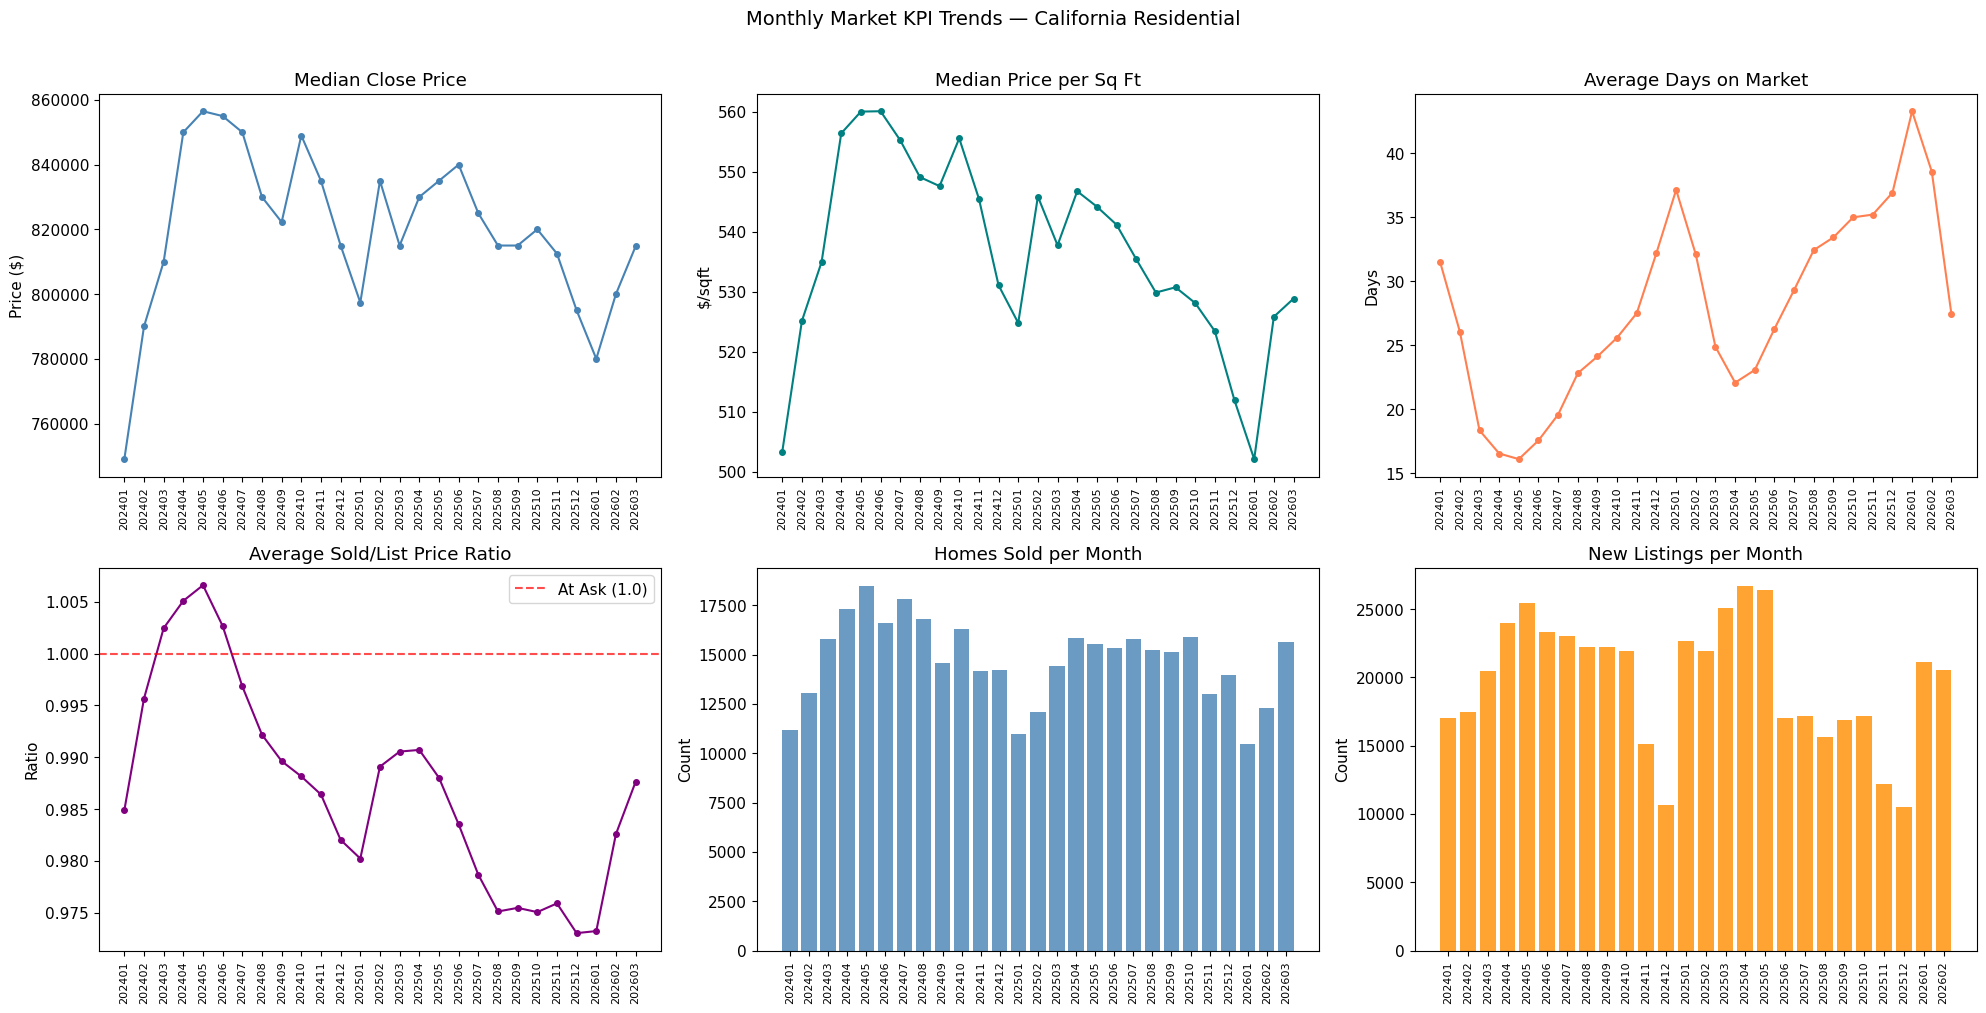

In [33]:
monthly_sold = monthly_sold_summary(sold)
monthly_listings = monthly_listing_summary(listings)
plot_monthly_kpi_trends(monthly_sold, monthly_listings)

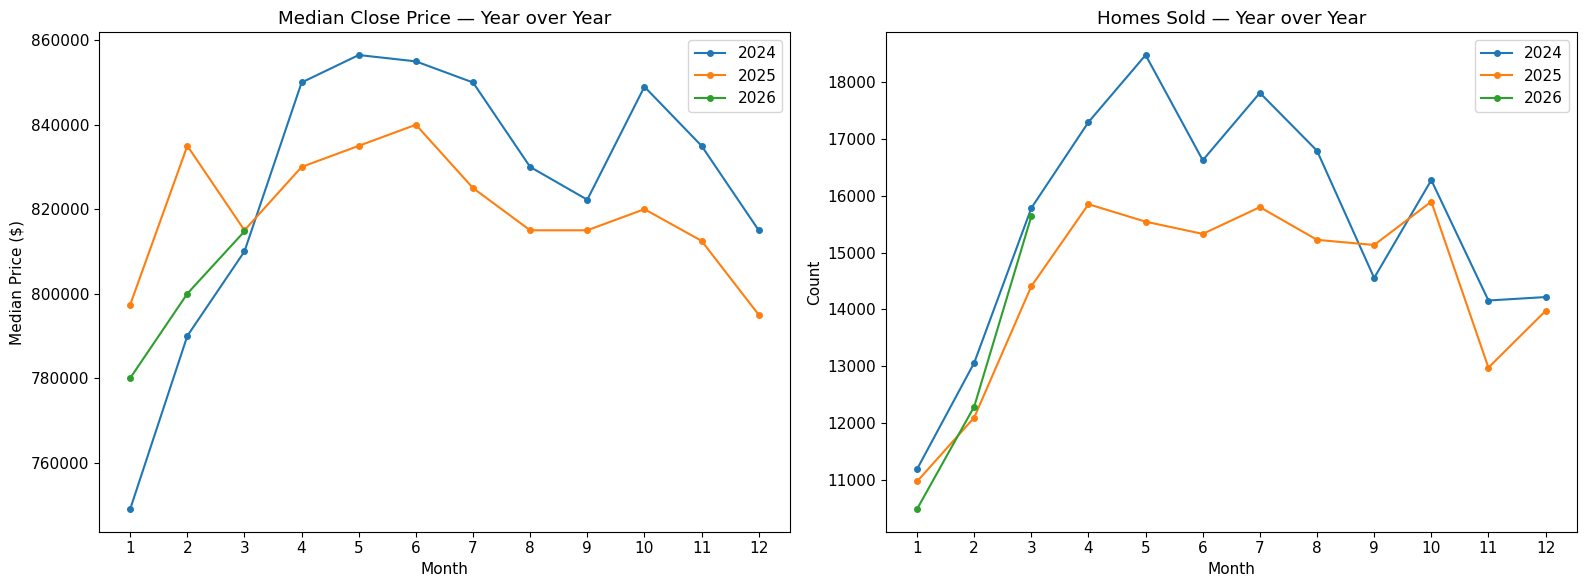

In [34]:
plot_yoy_comparison(sold)

### 6b. Supply vs. Demand

Compare new listing volume to closed sales volume over time. The ratio of these two indicates market tightness — a rising ratio means more inventory relative to demand.


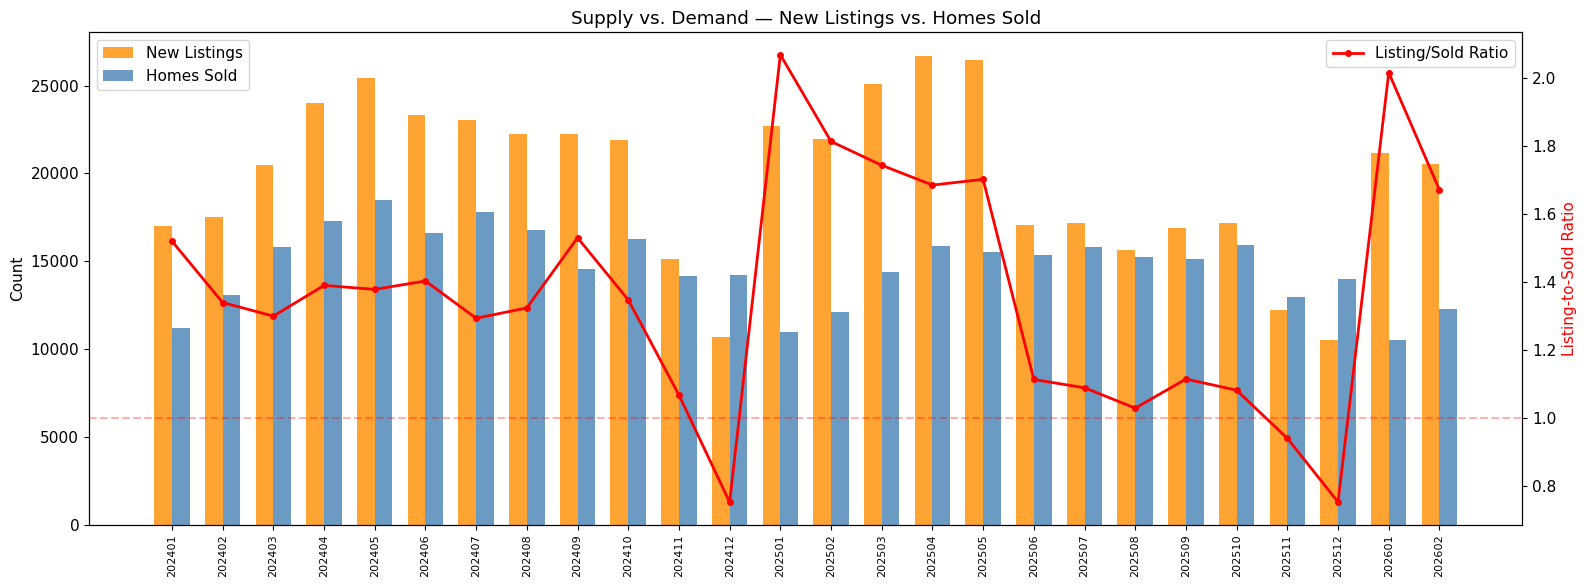

In [35]:
plot_supply_vs_demand(monthly_sold, monthly_listings)

### 6c. Geographic Analysis

Analyze market performance at the county and city level — the primary geographic dimensions used in the Tableau market analysis dashboard.


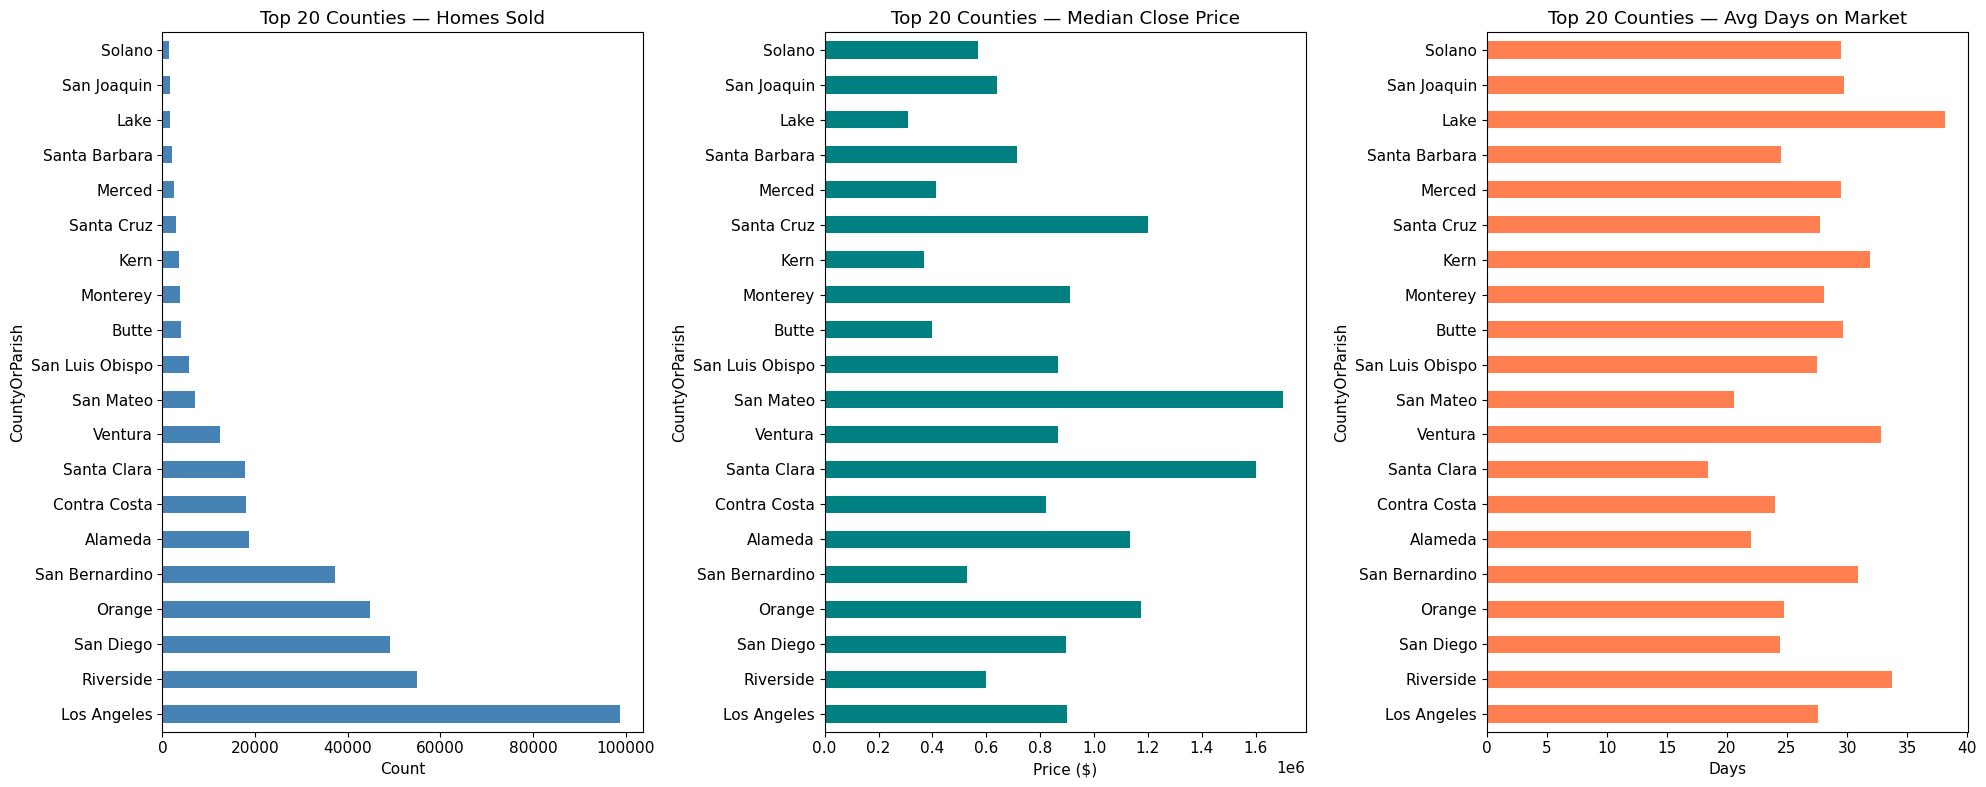

In [36]:
county_stats = geographic_summary(sold, 'CountyOrParish')
plot_top_counties(county_stats)

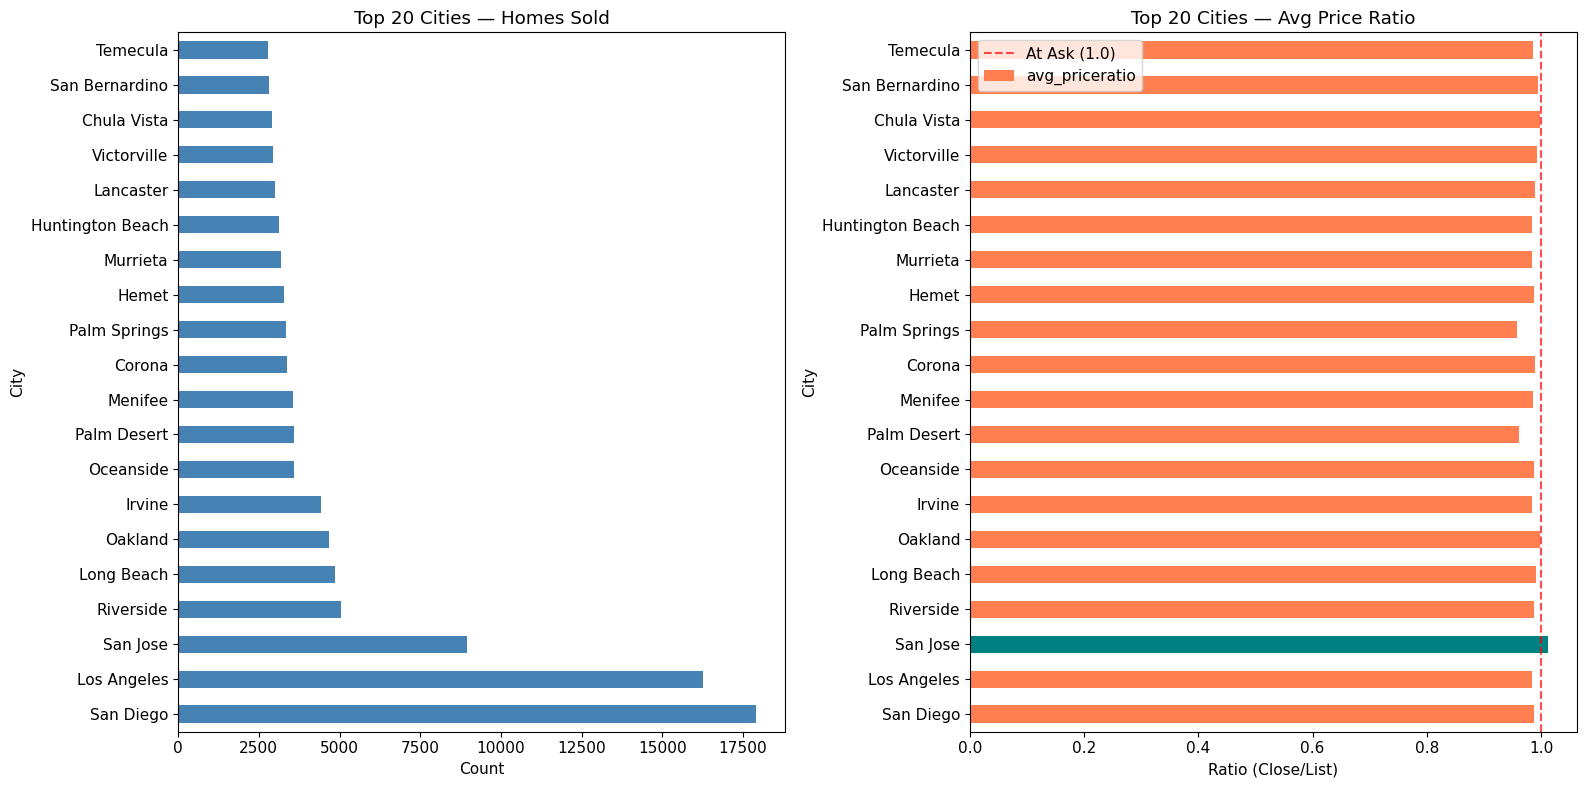

In [37]:
city_stats = geographic_summary(sold, 'City')
plot_top_cities(city_stats)

### 6d. Property Characteristics and Pricing Relationships

Explore how property attributes (size, bedrooms, year built, property subtype) relate to price and market velocity.


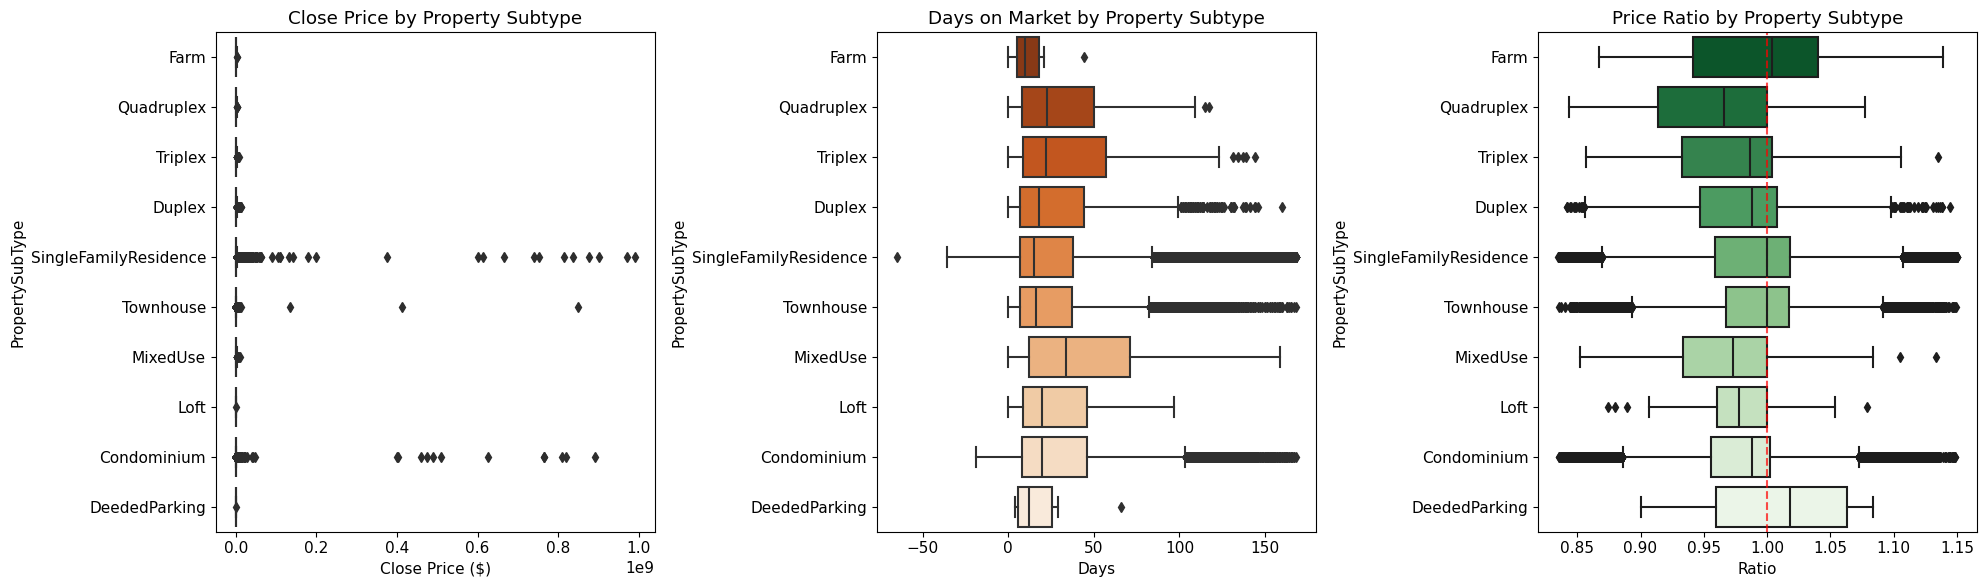

In [38]:
plot_subtype_comparison(sold)

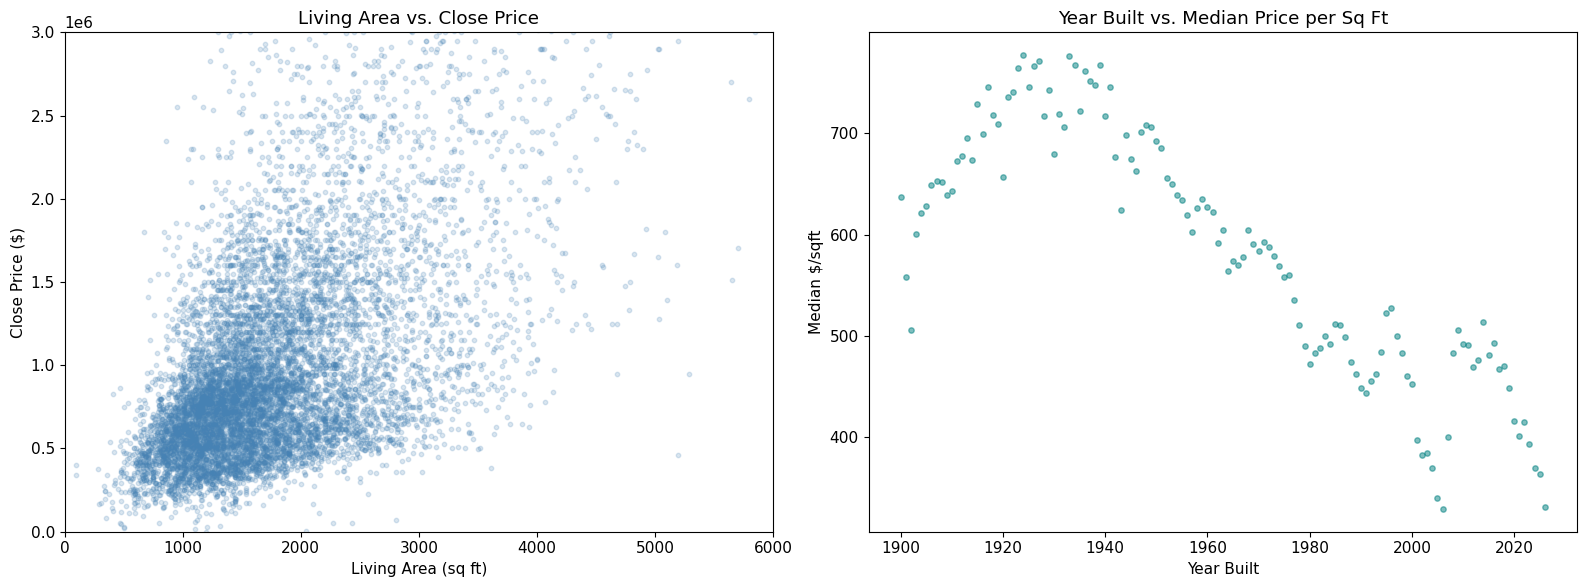

In [39]:
plot_price_vs_size(sold)

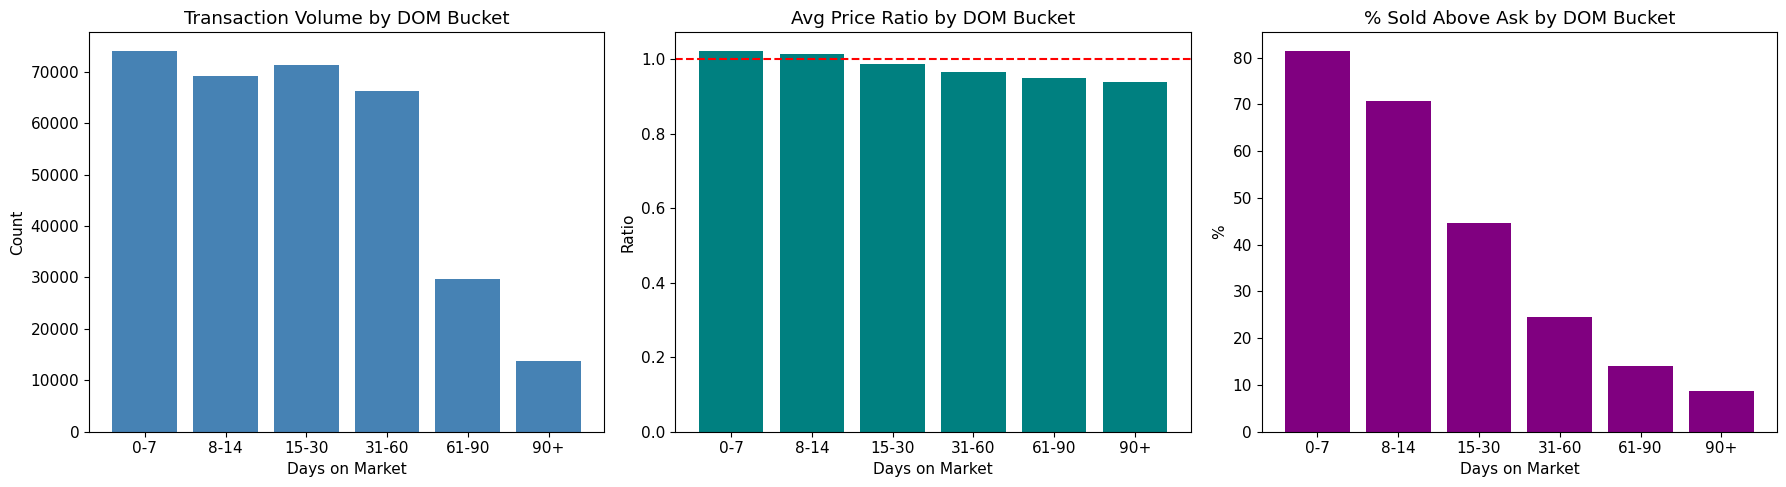

In [40]:
dom_analysis = dom_bucket_summary(sold)
plot_dom_bucket_analysis(dom_analysis)

### 6e. Price Reductions Analysis

Examine the prevalence and magnitude of price reductions across markets. High reduction rates signal softening demand — a key indicator for the market analysis dashboard.


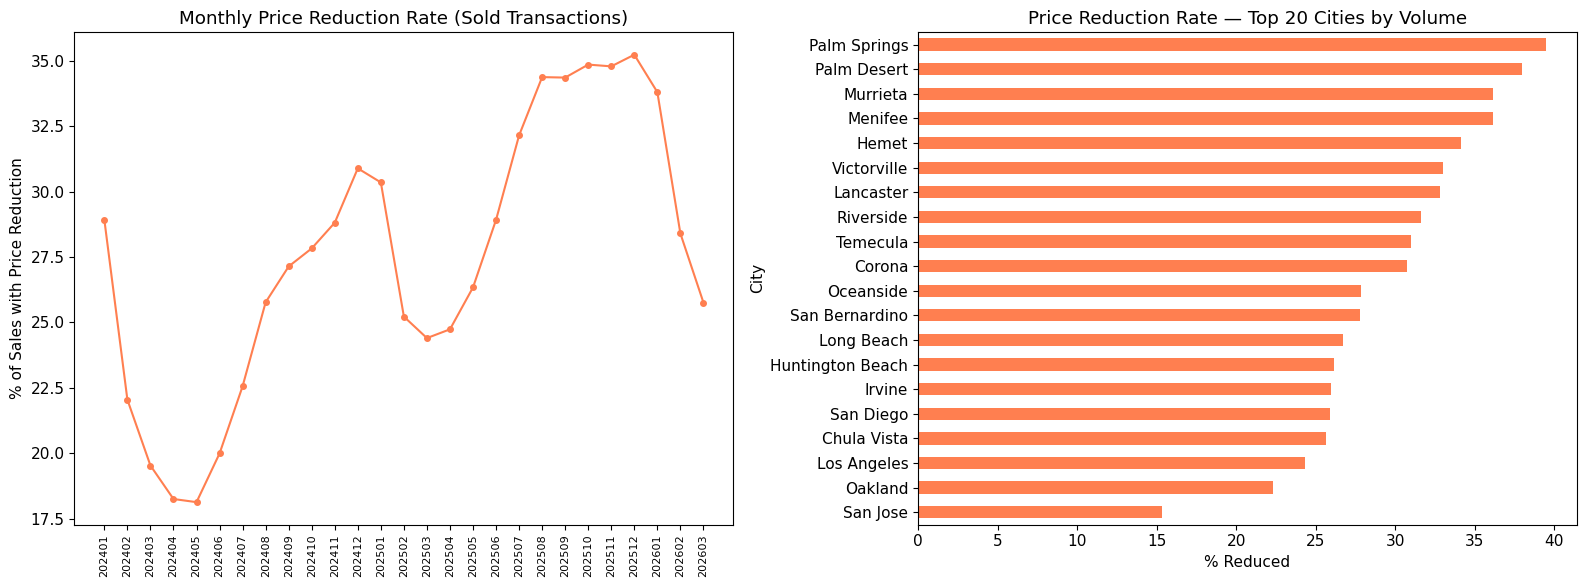

In [41]:
plot_price_reductions(sold)

### 6f. Competitive Analysis — Agent and Office Performance

Preliminary analysis of listing agent and office performance. These metrics feed directly into the Agent/Office Report Tableau dashboard.


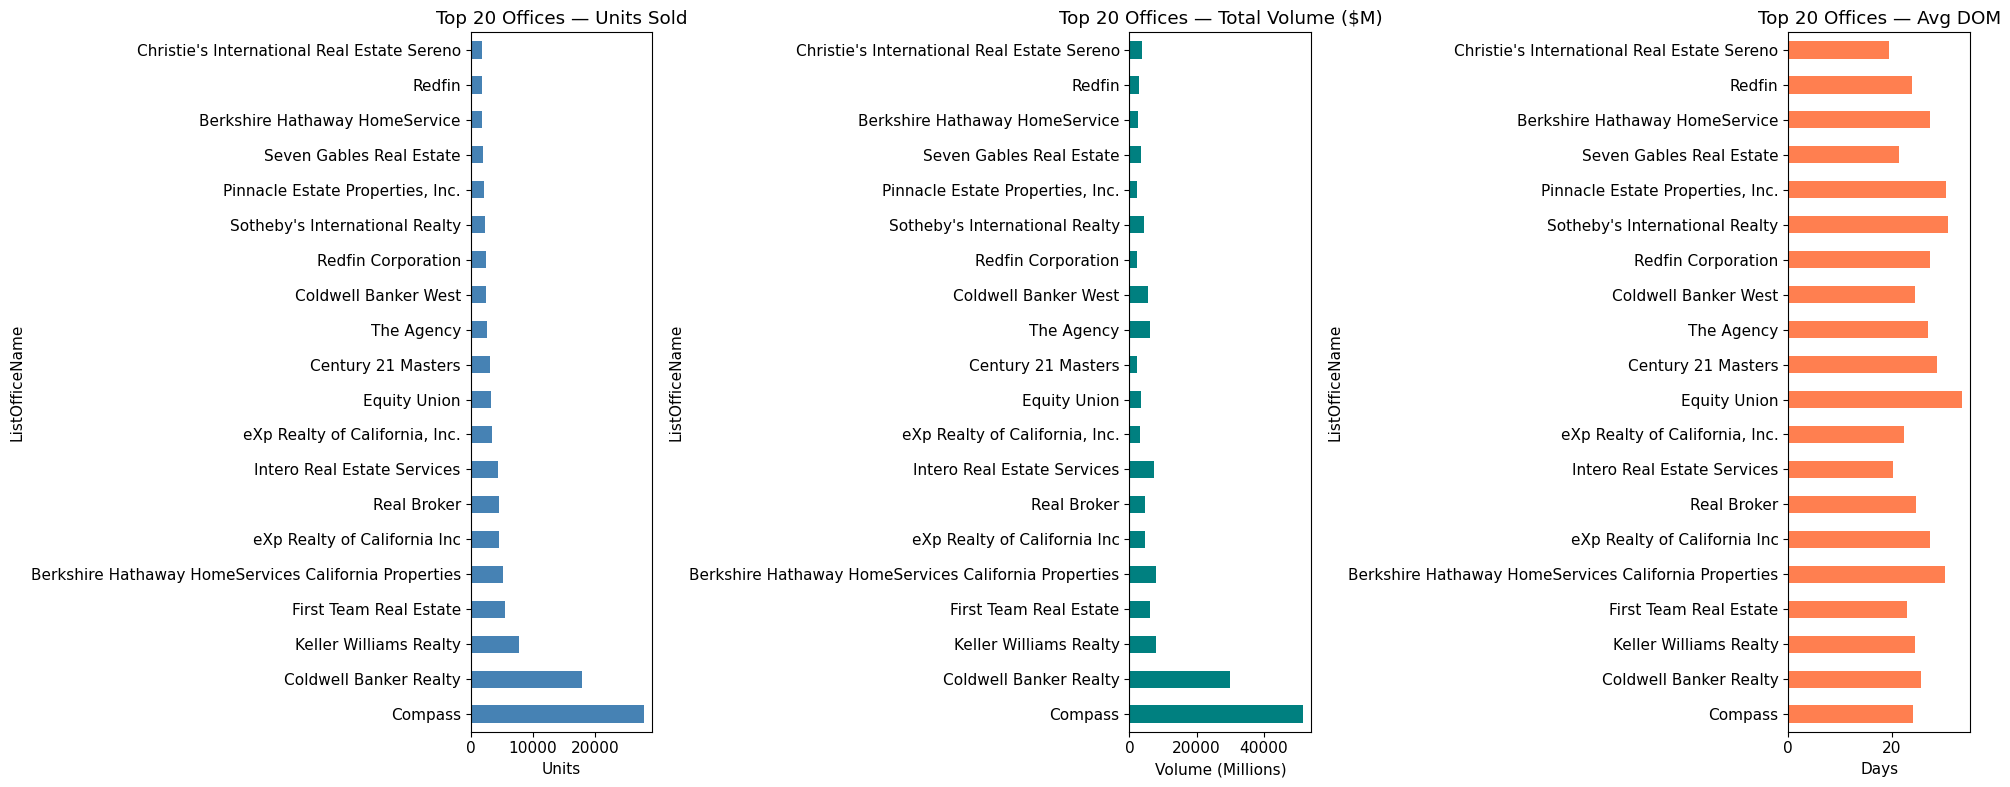

In [42]:
office_stats = competitive_summary(sold, 'ListOfficeName')
plot_top_offices(office_stats)

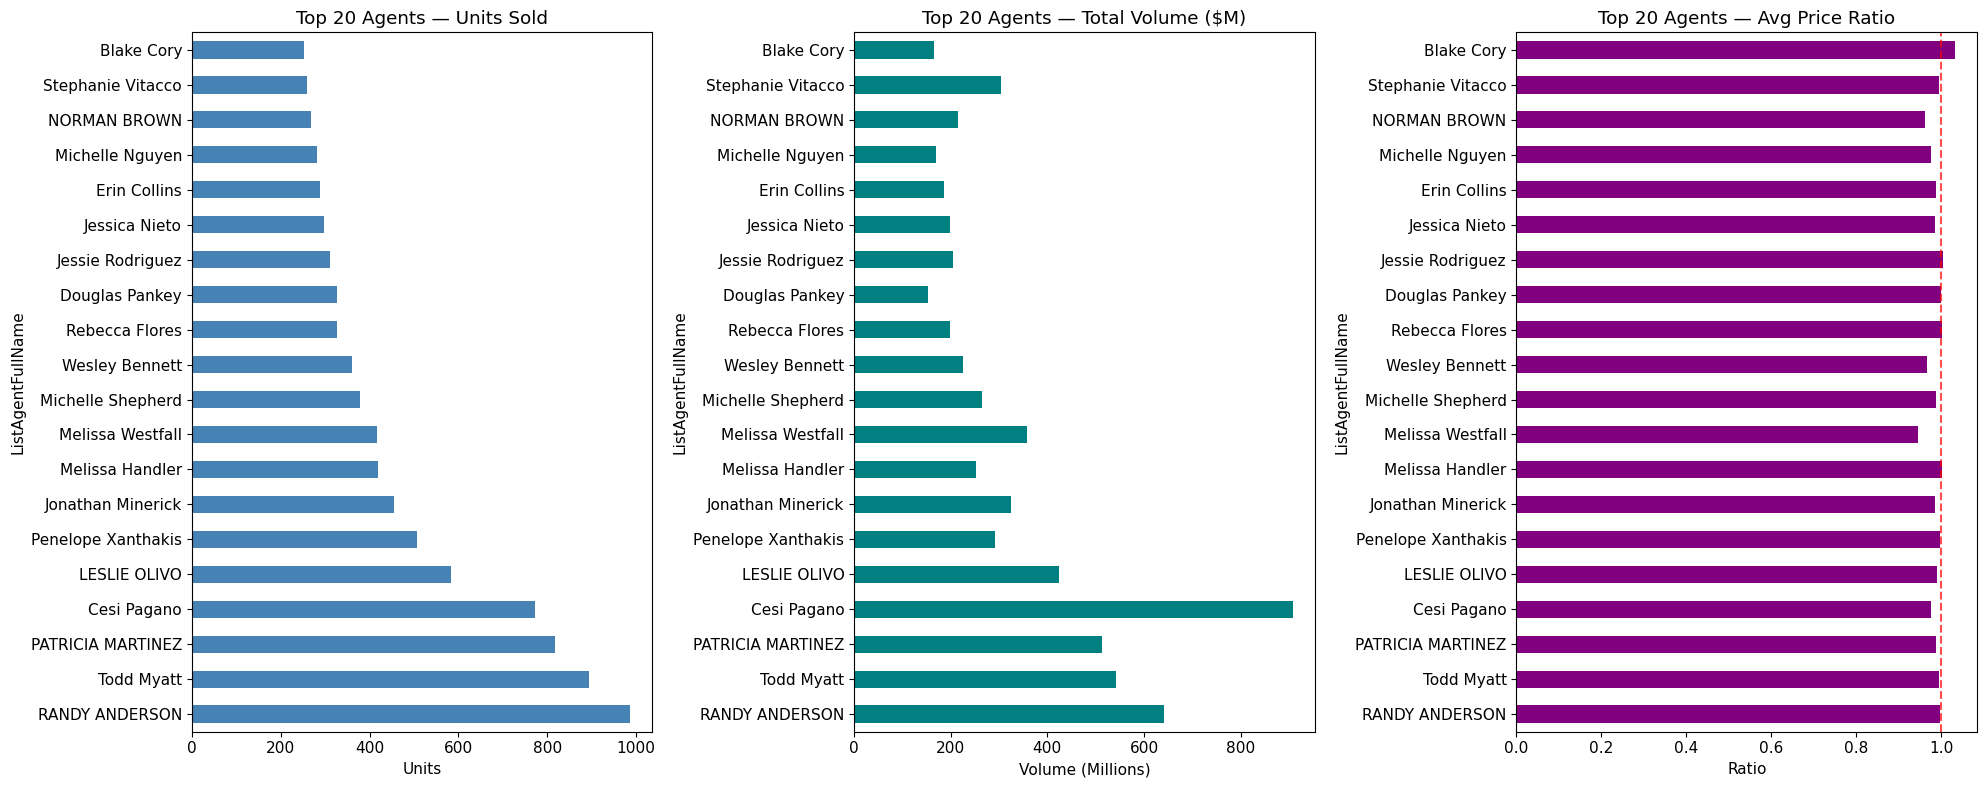

In [43]:
agent_stats = competitive_summary(sold, 'ListAgentFullName')
plot_top_agents(agent_stats)

### 6g. Correlation Analysis

Examine linear relationships between key numeric variables in the sold dataset to identify which features are most predictive of price, market velocity, and competitiveness.


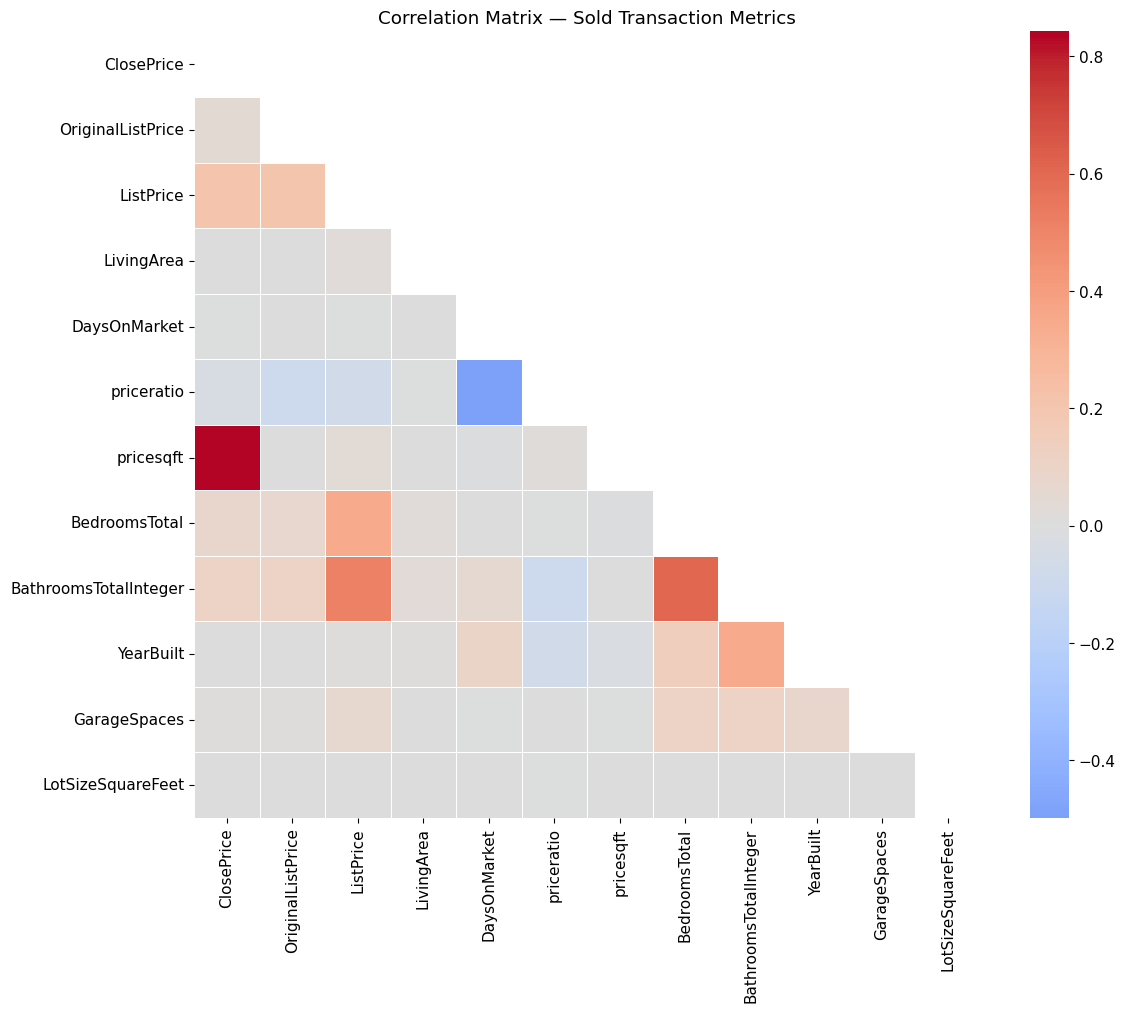

In [44]:
plot_correlation_heatmap(sold)

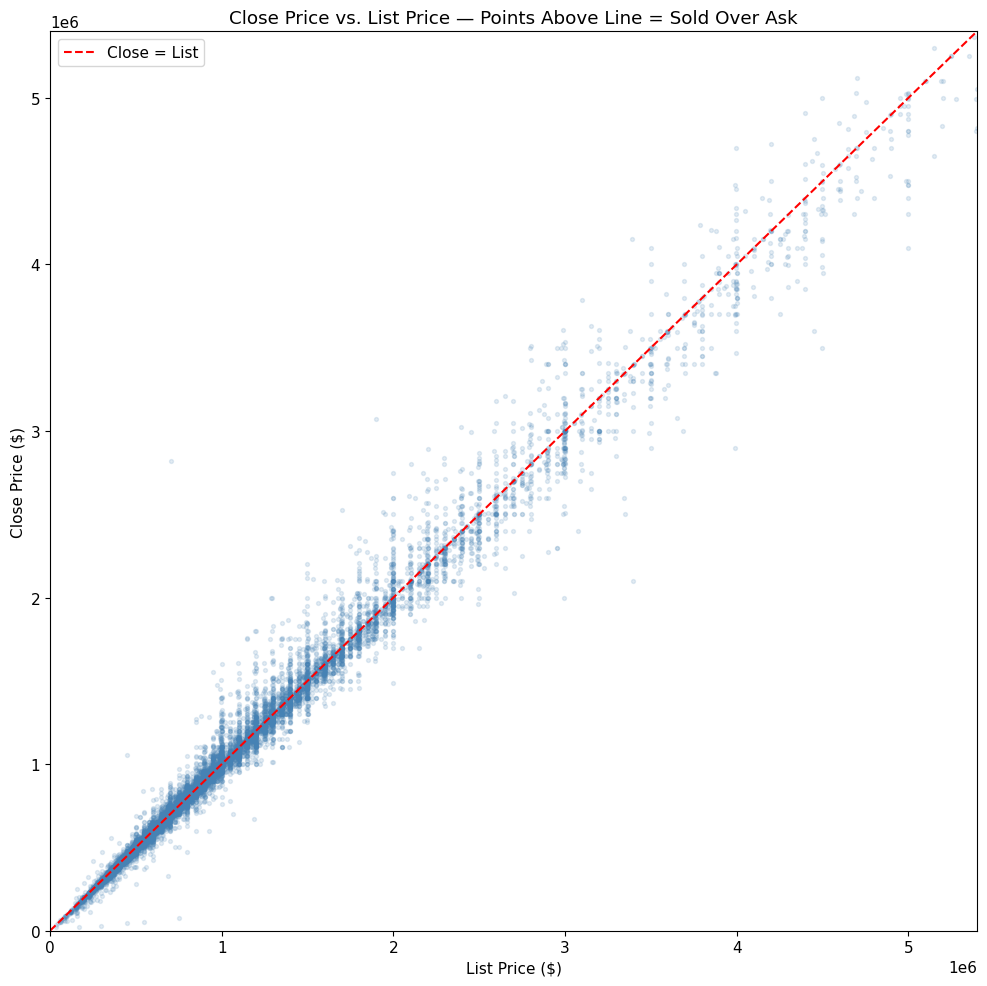

In [45]:
plot_close_vs_list(sold)

### 6h. Price Tier Analysis

Break down key metrics by price segment to understand how market dynamics differ across price points.


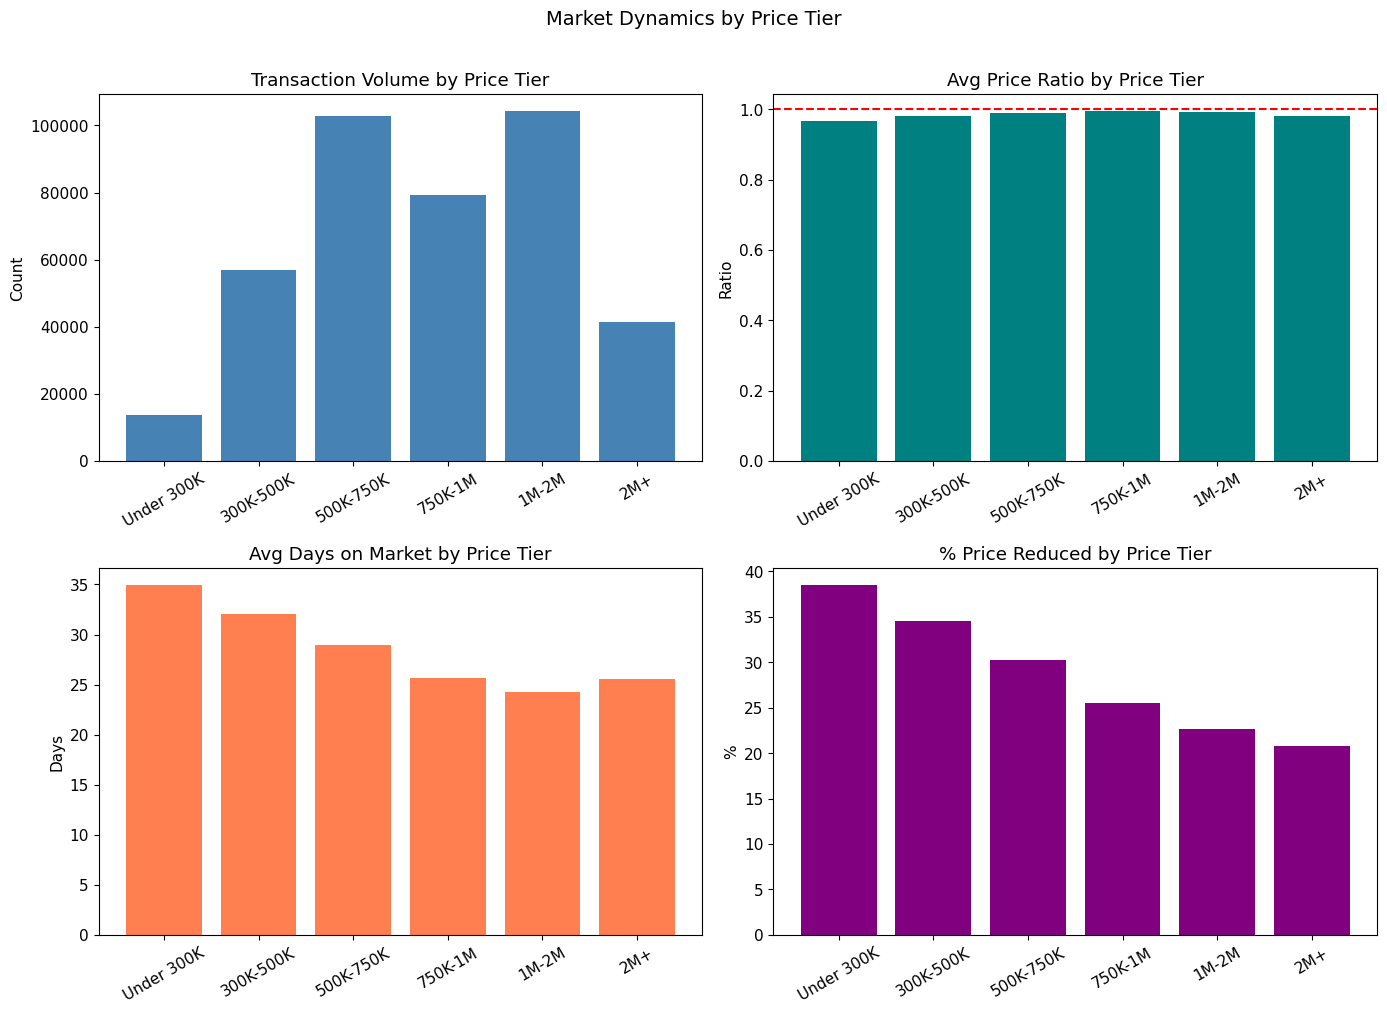

In [46]:
tier_stats = price_tier_summary(sold)
plot_price_tiers(tier_stats)

### 6i. New Construction vs. Existing Homes

New Construction vs. Existing Homes:
                    count  median_price  median_pricesqft  avg_dom  avg_priceratio
NewConstructionYN                                                                 
False              353334     825000.00            543.66    26.89            0.99
True                15058     665538.50            348.76    36.50            0.99


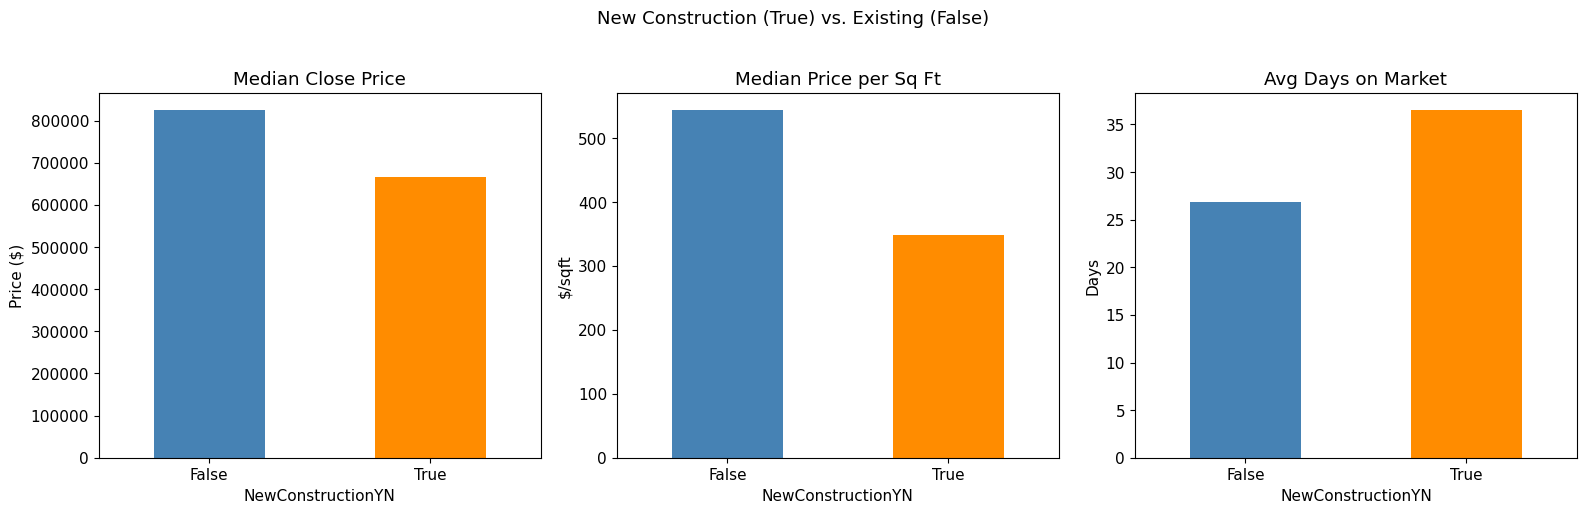

In [47]:
plot_new_construction(sold)

---
## 7. Summary Statistics for Tableau

Generate a concise summary table of the key metrics that will populate the Tableau dashboards.


In [48]:
market_summary(sold, listings)

CALIFORNIA RESIDENTIAL MARKET SUMMARY
Period: 2024-01-01 to 2026-03-31
Total closed transactions:    397,887
Total new listings:           514,182
Median close price:           $820,000
Median price per sq ft:       $537
Avg days on market:           27.3
Avg sold/list price ratio:    0.9878
% sold above ask:             44.2%
% with price reduction:       27.2%
Unique cities:                1123
Unique counties:              63
Unique ZIP codes:             3584
Unique listing offices:       18414
Unique listing agents:        76811


---
## 8. Key Findings

### Market Trends
- **397,887 closed transactions and 514,182 new listings** across 27 months (Jan 2024 — Mar 2026) of California residential MLS data.
- **Median close price is $820,000** — California's residential market remains firmly high-priced.
- **Average sold/list ratio of 0.9878** means the typical home sells ~1.2% below ask. However, **44.2% of transactions close at or above asking price**, indicating a split market.
- **Average DOM of 27.3 days**, with the median at 16 days. The right-skewed distribution confirms **median is the correct aggregation for DOM in Tableau**.
- Monthly KPI trends show **clear seasonality**: price peaks in late spring/summer, troughs in winter.

### Transaction Timeline
- **Median listing-to-contract: 25 days** (mean 45.1 days) — most homes go under contract within a month, but a long tail of slow-moving listings pulls the mean up.
- **Median contract-to-close: 29 days** (mean 31.7 days) — escrow is tightly clustered around 4 weeks, much less variable than the listing phase.
- **Santa Clara County has the fastest listing-to-contract at 9 days** with a price ratio of 1.01 (above ask) — the most competitive market in the state.
- **Lake County is the slowest at 58 days** listing-to-contract with a 0.96 ratio — a clear buyer's market.

### Segment Analysis
- **Single Family Residence dominates** at 297,540 transactions (74.8%) with a median price of $890K.
- **Condos sell 17% cheaper** ($628K median) but have **higher PPSF ($566 vs $532)** than single family — smaller units at premium per-sqft pricing.
- **Manufactured homes sit longest** (median 64 days listing-to-contract) at the lowest price ratio (0.94).
- **Compass leads both listing (27,831 units) and buying sides (25,951 units)**, with a median price of $1.35M — positioned in the luxury segment.
- **Intero Real Estate** has the highest price ratio (1.01) and fastest listing-to-contract (11 days) among top offices.

### Supply vs. Demand
- **514,182 new listings vs. 397,887 closed transactions**. Listing-to-sold ratio of ~1.29:1.
- The ratio trend line is a leading indicator for price direction.

### Geographic Patterns
- **Los Angeles leads volume (98,879 sales)** at $900K median, followed by Riverside (55K), San Diego (49K), and Orange County (45K).
- **Orange County median $1.175M, San Mateo $1.7M, Santa Clara $1.6M** — coastal/tech counties command significant premiums.
- **Alameda and Santa Clara counties have price ratios at or above 1.00** — the only counties where the median home sells at or above ask.

### Price Ratio and DOM Insights
- **DaysOnMarket and priceratio have the strongest negative correlation at -0.50** — the most actionable relationship in the dataset.
- Homes selling in 0-7 days have the highest average price ratio; 90+ day homes sell well below ask.
- **Market condition split: 175,937 seller's market vs. 221,950 buyer's market** transactions.

### Mortgage Rate Context
- **30-year fixed mortgage rates** (FRED MORTGAGE30US) merged onto both datasets at monthly granularity.
- Zero null values after merge — full rate coverage from Jan 2024 through Mar 2026.
- Rate trends (ranging ~6.3%–7.5% over this period) provide context for interpreting volume and price shifts in Tableau.

### Data Quality & Cleaning
- **Date consistency:** 295 records (0.07%) flagged — 58 listing-after-close, 239 purchase-after-close.
- **Invalid numerics:** 183 sold records flagged (0.05%) — 1 ClosePrice ≤ 0, 144 LivingArea ≤ 0, 38 negative DOM.
- **Geographic issues:** 4,133 sold (1.04%), 80,133 listings (15.5%) — primarily missing coordinates.
- All flags are additive (no rows deleted), preserving the full dataset.

### Correlation Analysis
- **ClosePrice to pricesqft (0.84):** Validates $/sqft as the core normalization metric.
- **BathroomsTotalInteger to ListPrice (0.52):** Bathrooms are a stronger price predictor than bedrooms.

### Price Reductions
- **27.2% of closed sales had price reductions** (108,227 of 397,887). City-level rates vary from <20% to >30%.

### New Construction vs. Existing
- Existing homes: median $825K at $544/sqft. New construction: median $666K at $349/sqft.
- New construction is cheaper per sqft but sits longer on market (36.5 vs 26.9 days).

### Tableau Focus Areas
1. **DOM vs. Price Ratio** — strongest finding
2. **Listing-to-contract days by geography** — reveals competitive vs. soft markets
3. **Monthly KPI trends with YOY overlay** — clear seasonality
4. **Mortgage rate overlay on volume/price trends** — rate impact on market activity
5. **City/county-level price ratio maps** — geographic competitiveness varies dramatically
6. **Supply vs. demand time series** — leading market indicator
7. **Top offices competitive dashboard** — Compass, Coldwell Banker, Intero performance comparison
